![clothing_classification](figures/clothing_classification.png)

### Project Goal

As a data scientist for the new e-commerce retailer, Fashion Forward, I have been tasked with developing a robust garment classifier. The primary objective is to build a deep learning model that accurately categorizes product images into 10 distinct classes (e.g., T-shirt, Trouser, Coat). This automated system is critical for streamlining the product listing process, enhancing customer search experience, and improving inventory management.

### My Approach

To solve this problem, I will follow a structured data science workflow:

1.  **Data Exploration and Preparation**: I will start by performing an Exploratory Data Analysis (EDA) on the FashionMNIST dataset to understand its characteristics and prepare it for modeling. This includes creating a validation set to properly evaluate model performance during training.
2.  **Baseline Model**: I will define and train a simple Convolutional Neural Network (CNN) as a baseline to establish an initial performance benchmark.
3.  **Iterative Improvement**: I will systematically improve upon the baseline by conducting experiments, such as increasing training duration and deepening the network architecture. I will track training and validation metrics to diagnose model behavior.
4.  **Final Evaluation**: I will select the best-performing model and conduct a final, comprehensive evaluation on the held-out test set. This will include generating a confusion matrix to analyze class-specific performance and identify common misclassifications.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# Import functions from our refactored scripts
from src.data_loader import get_data_loaders
from src.model import BaselineCNN, DeeperCNN
from src.train import train_and_validate
from src.evaluate import evaluate_model
from src.visualization import show_random_samples, plot_history
from src.utils import set_seed

# Set seed for reproducibility
set_seed(42)

# Set the style for the plots
sns.set_theme(style="whitegrid")

In [2]:
# Set device for training
# To easily switch between GPU and CPU, change the `force_cpu` flag.
force_cpu = False # Set to True to force CPU usage
# force_cpu = True # Set to True to force CPU usage


if not force_cpu and torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA (NVIDIA GPU)")
elif not force_cpu and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Selected device: {device}")

Using MPS (Apple Silicon GPU)
Selected device: mps


In [3]:
# Load the data using the refactored function
train_loader, val_loader, test_loader, classes = get_data_loaders(batch_size=64)
num_classes = len(classes)

# To get the full dataset for EDA, we can access it from one of the loaders
full_train_data = train_loader.dataset.dataset

print(f"Classes: {classes}")
print(f"Number of classes: {num_classes}")

Number of training examples: 48000
Number of validation examples: 12000
Number of testing examples: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Number of classes: 10


In [4]:
# Get the length of each dataset
train_size = len(train_loader.dataset)
val_size = len(val_loader.dataset)
test_size = len(test_loader.dataset)

print(f"Size of the training set: {train_size} samples")
print(f"Size of the validation set: {val_size} samples")
print(f"Size of the test set: {test_size} samples")

Size of the training set: 48000 samples
Size of the validation set: 12000 samples
Size of the test set: 10000 samples


### Exploratory Data Analysis

Before building the model, I will perform an Exploratory Data Analysis (EDA) to understand the dataset's characteristics. This involves checking the class distribution to ensure it is balanced and visualizing sample images to get a qualitative sense of the classification task.

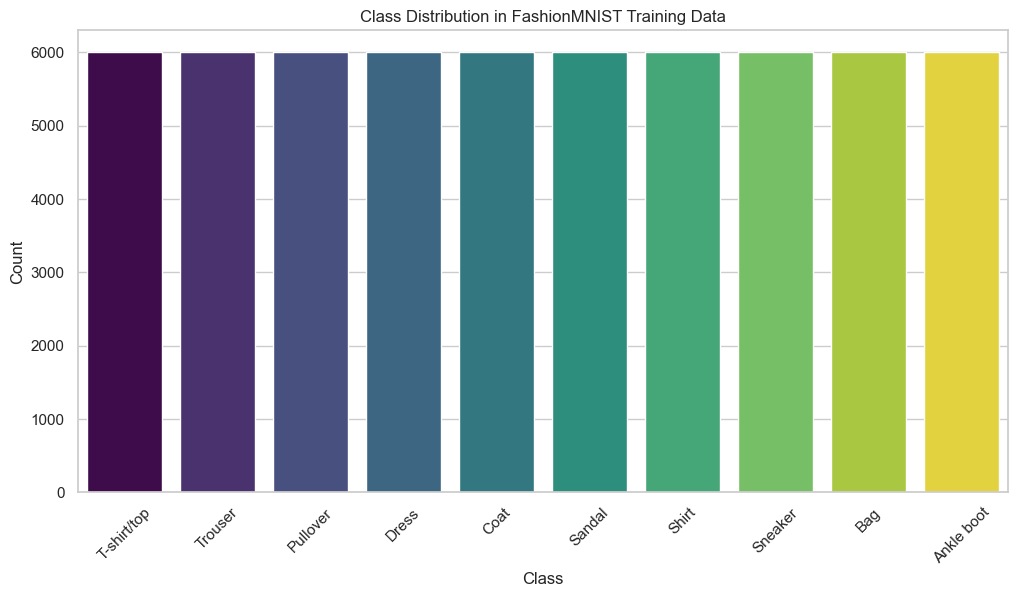

In [5]:
# Visualize class distribution
plt.figure(figsize=(12, 6))
# We use the targets from the full training dataset to get the overall distribution
sns.countplot(x=full_train_data.targets, hue=full_train_data.targets, palette="viridis", legend=False)
plt.title('Class Distribution in FashionMNIST Training Data')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=range(num_classes), labels=classes, rotation=45)
plt.savefig('./figures/class_distribution.png')
plt.show()

Image size for Training Set: 28x28 pixels


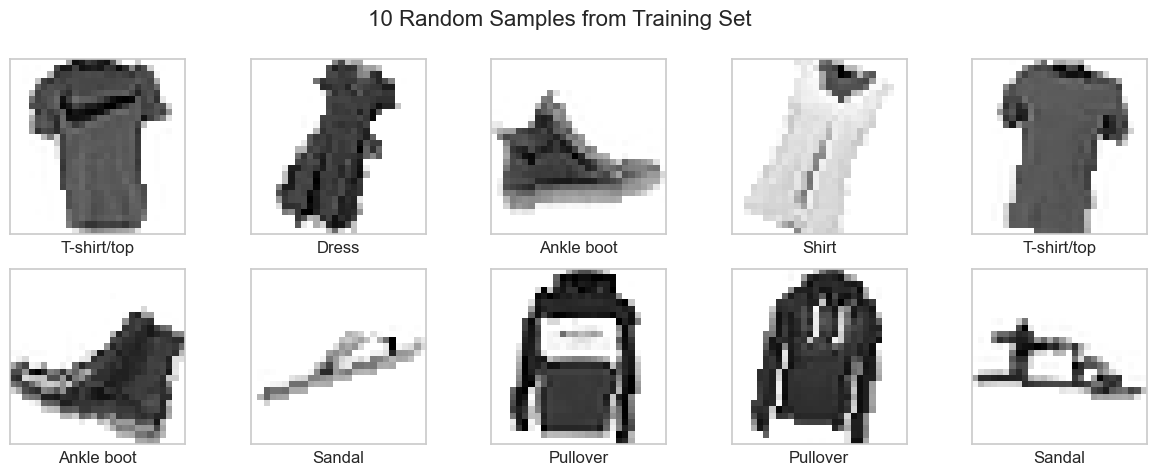

Image size for Validation Set: 28x28 pixels


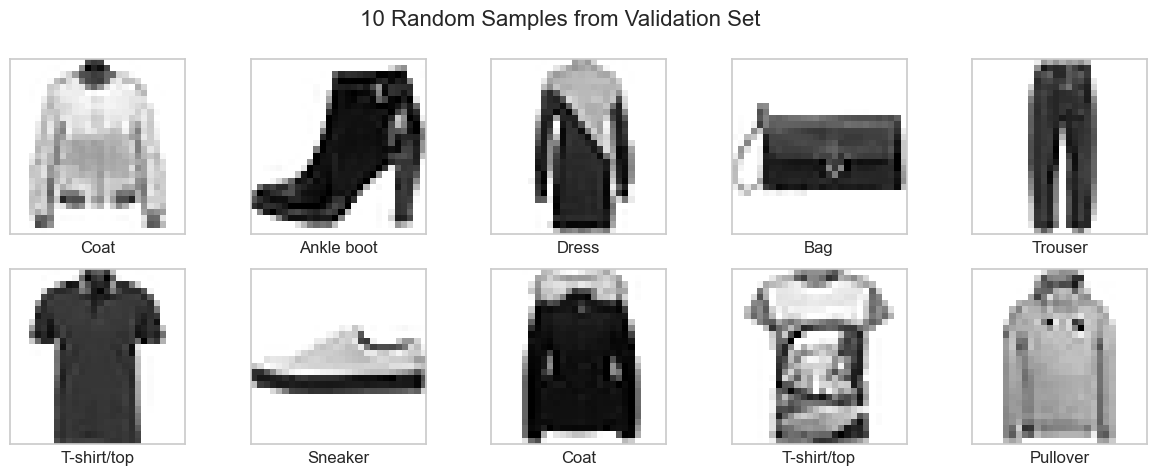

Image size for Test Set: 28x28 pixels


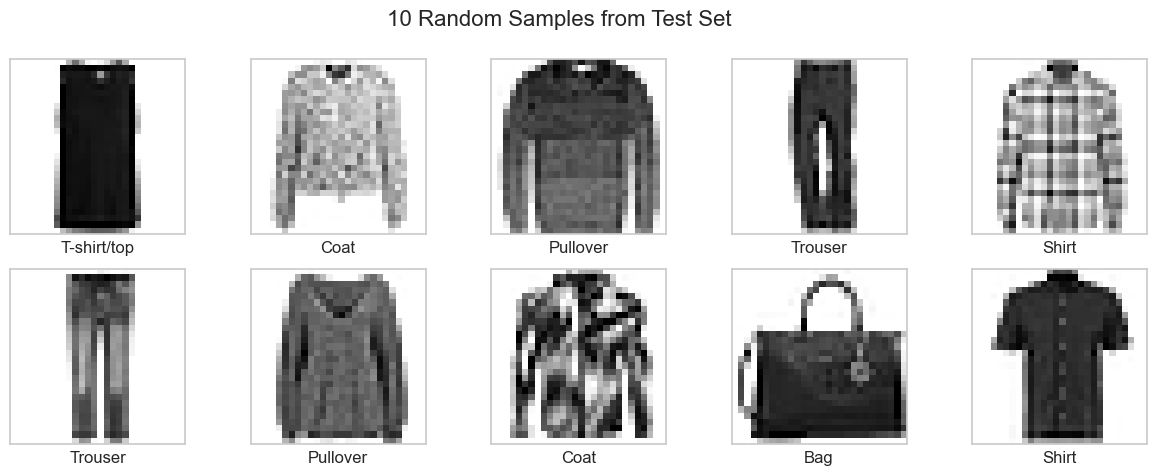

In [6]:
# Display samples from each loader
show_random_samples(train_loader, 'Training Set', classes)
show_random_samples(val_loader, 'Validation Set', classes)
show_random_samples(test_loader, 'Test Set', classes)

In [7]:
# Look at the train_loader
# Retrieve the first batch of data
first_batch_images, first_batch_labels = next(iter(train_loader))

# Retrieve the very first image and label from the batch
first_image_tensor = first_batch_images[0]
first_label_tensor = first_batch_labels[0]

# Print the tensors
print("--- First Element Tensors ---")
print("\nImage Tensor Shape:", first_image_tensor.shape)
print("Image Tensor:")
print(first_image_tensor)

print("\nLabel Tensor Shape:", first_label_tensor.shape)
print("Label Tensor:")
print(first_label_tensor)

--- First Element Tensors ---

Image Tensor Shape: torch.Size([1, 28, 28])
Image Tensor:
tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0

### Experiment 1: Baseline CNN Model

I will begin by training the simple, single-layer `BaselineCNN` for a limited number of epochs. This will provide a performance baseline and allow me to verify that the training pipeline is working correctly. I selected `Adam` as the optimizer and `CrossEntropyLoss` as the criterion, which are standard and effective choices for this type of multi-class classification problem.

Training Baseline CNN...
Epoch 1/5 | Train Loss: 0.6410, Train Acc: 0.7717 | Val Loss: 0.4828, Val Acc: 0.8387 | LR: 0.00100000
Epoch 1/5 | Train Loss: 0.6410, Train Acc: 0.7717 | Val Loss: 0.4828, Val Acc: 0.8387 | LR: 0.00100000
Epoch 2/5 | Train Loss: 0.4928, Train Acc: 0.8253 | Val Loss: 0.4451, Val Acc: 0.8415 | LR: 0.00100000
Epoch 2/5 | Train Loss: 0.4928, Train Acc: 0.8253 | Val Loss: 0.4451, Val Acc: 0.8415 | LR: 0.00100000
Epoch 3/5 | Train Loss: 0.4513, Train Acc: 0.8408 | Val Loss: 0.4285, Val Acc: 0.8488 | LR: 0.00100000
Epoch 3/5 | Train Loss: 0.4513, Train Acc: 0.8408 | Val Loss: 0.4285, Val Acc: 0.8488 | LR: 0.00100000
Epoch 4/5 | Train Loss: 0.4326, Train Acc: 0.8480 | Val Loss: 0.4061, Val Acc: 0.8615 | LR: 0.00100000
Epoch 4/5 | Train Loss: 0.4326, Train Acc: 0.8480 | Val Loss: 0.4061, Val Acc: 0.8615 | LR: 0.00100000
Epoch 5/5 | Train Loss: 0.4157, Train Acc: 0.8535 | Val Loss: 0.3869, Val Acc: 0.8642 | LR: 0.00100000
Plot saved to ./figures/experiment_1_history.png

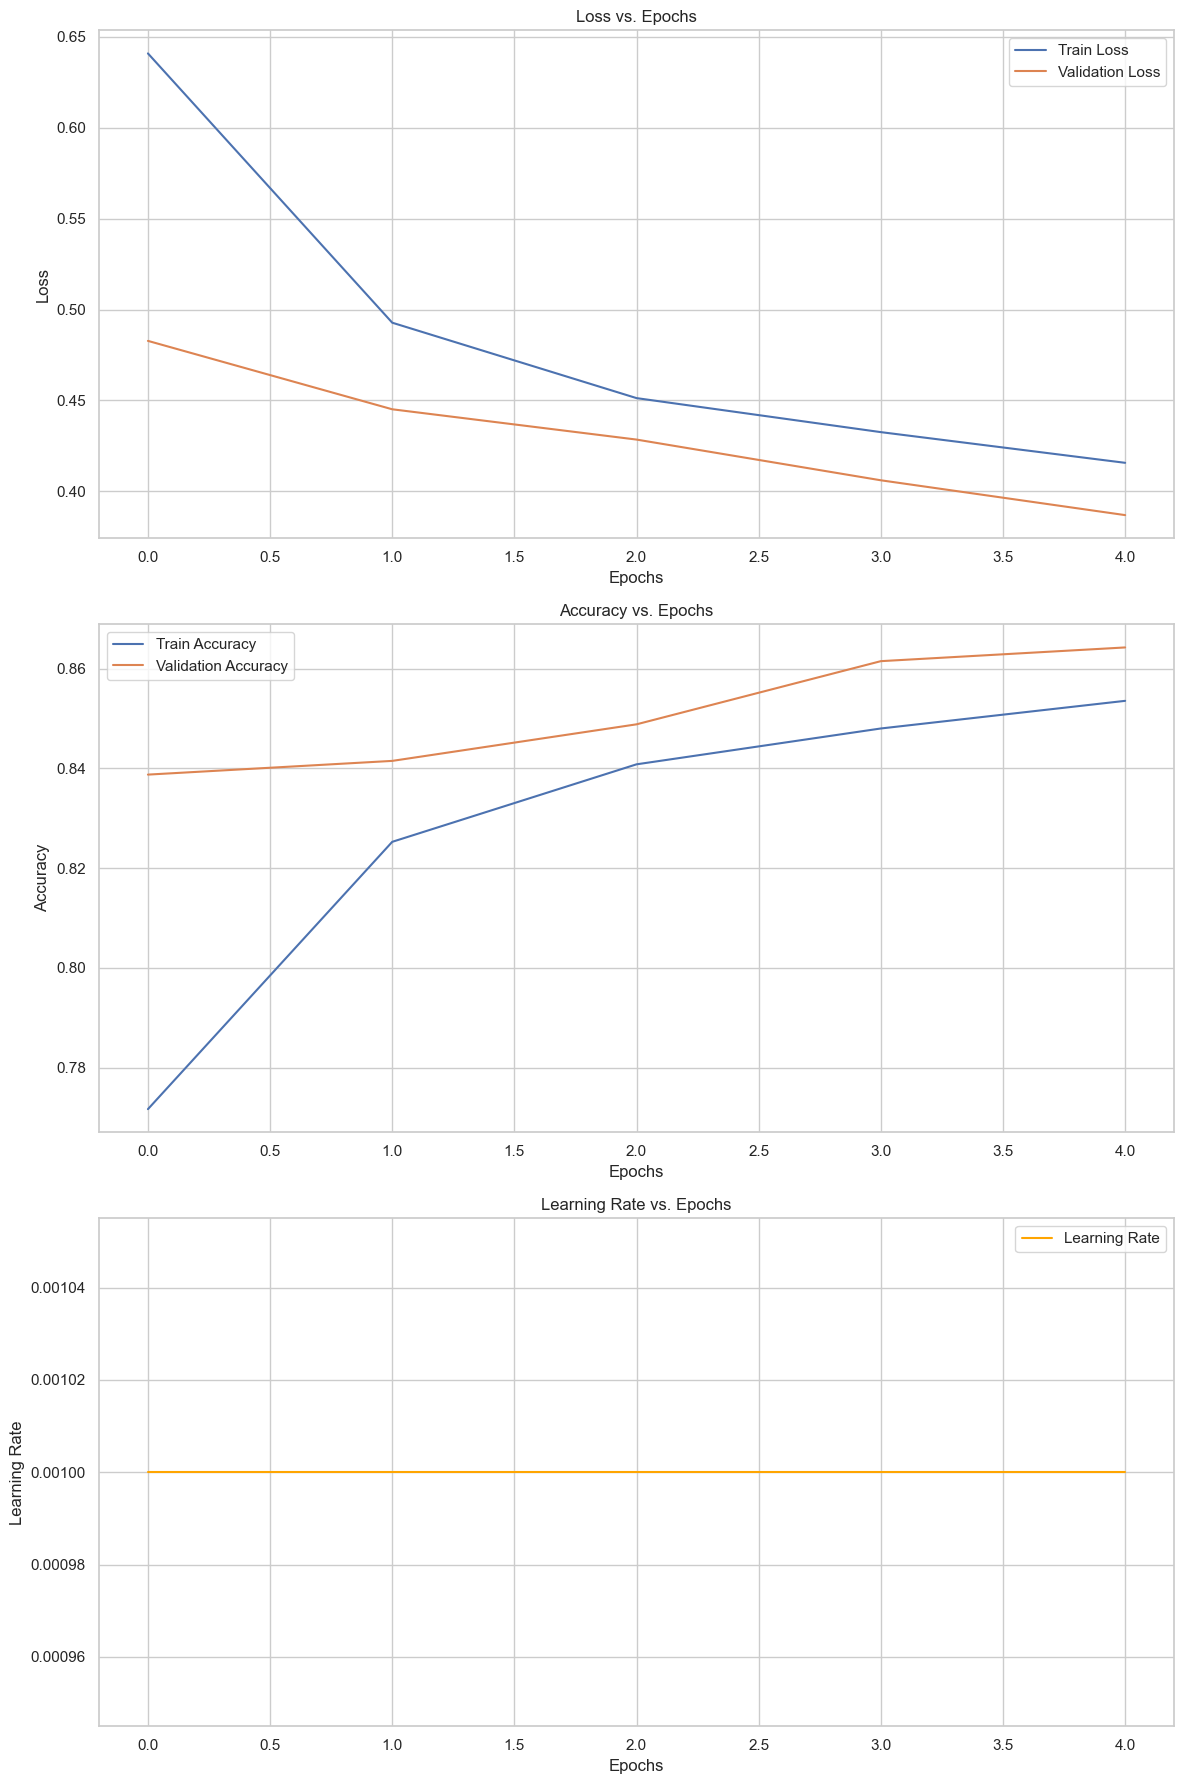

In [15]:
# Instantiate the baseline model, optimizer, and loss function
baseline_model = BaselineCNN(num_classes=num_classes)
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train for 5 epochs
print("Training Baseline CNN...")
baseline_history = train_and_validate(
    model=baseline_model,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=5,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes,
    device=device
)

# Plot the results
plot_history(baseline_history, save_path='./figures/experiment_1_history.png')

### Experiment 1: CPU vs. GPU Comparison

To quantify the benefits of GPU acceleration, this experiment runs the `BaselineCNN` for 5 epochs on both the CPU and the available GPU (`mps` or `cuda`). It measures and compares the training time for each, providing a clear speedup metric.

--- Starting Experiment 1a: Baseline CNN on CPU ---
Epoch 1/5 | Train Loss: 0.6401, Train Acc: 0.7716 | Val Loss: 0.4762, Val Acc: 0.8327 | LR: 0.001000
Epoch 1/5 | Train Loss: 0.6401, Train Acc: 0.7716 | Val Loss: 0.4762, Val Acc: 0.8327 | LR: 0.001000
Epoch 2/5 | Train Loss: 0.4857, Train Acc: 0.8289 | Val Loss: 0.4516, Val Acc: 0.8470 | LR: 0.001000
Epoch 2/5 | Train Loss: 0.4857, Train Acc: 0.8289 | Val Loss: 0.4516, Val Acc: 0.8470 | LR: 0.001000
Epoch 3/5 | Train Loss: 0.4458, Train Acc: 0.8406 | Val Loss: 0.4219, Val Acc: 0.8536 | LR: 0.001000
Epoch 3/5 | Train Loss: 0.4458, Train Acc: 0.8406 | Val Loss: 0.4219, Val Acc: 0.8536 | LR: 0.001000
Epoch 4/5 | Train Loss: 0.4276, Train Acc: 0.8483 | Val Loss: 0.3948, Val Acc: 0.8642 | LR: 0.001000
Epoch 4/5 | Train Loss: 0.4276, Train Acc: 0.8483 | Val Loss: 0.3948, Val Acc: 0.8642 | LR: 0.001000
Epoch 5/5 | Train Loss: 0.4122, Train Acc: 0.8539 | Val Loss: 0.4077, Val Acc: 0.8608 | LR: 0.001000
CPU Training Time: 54.08 seconds
Epoch 

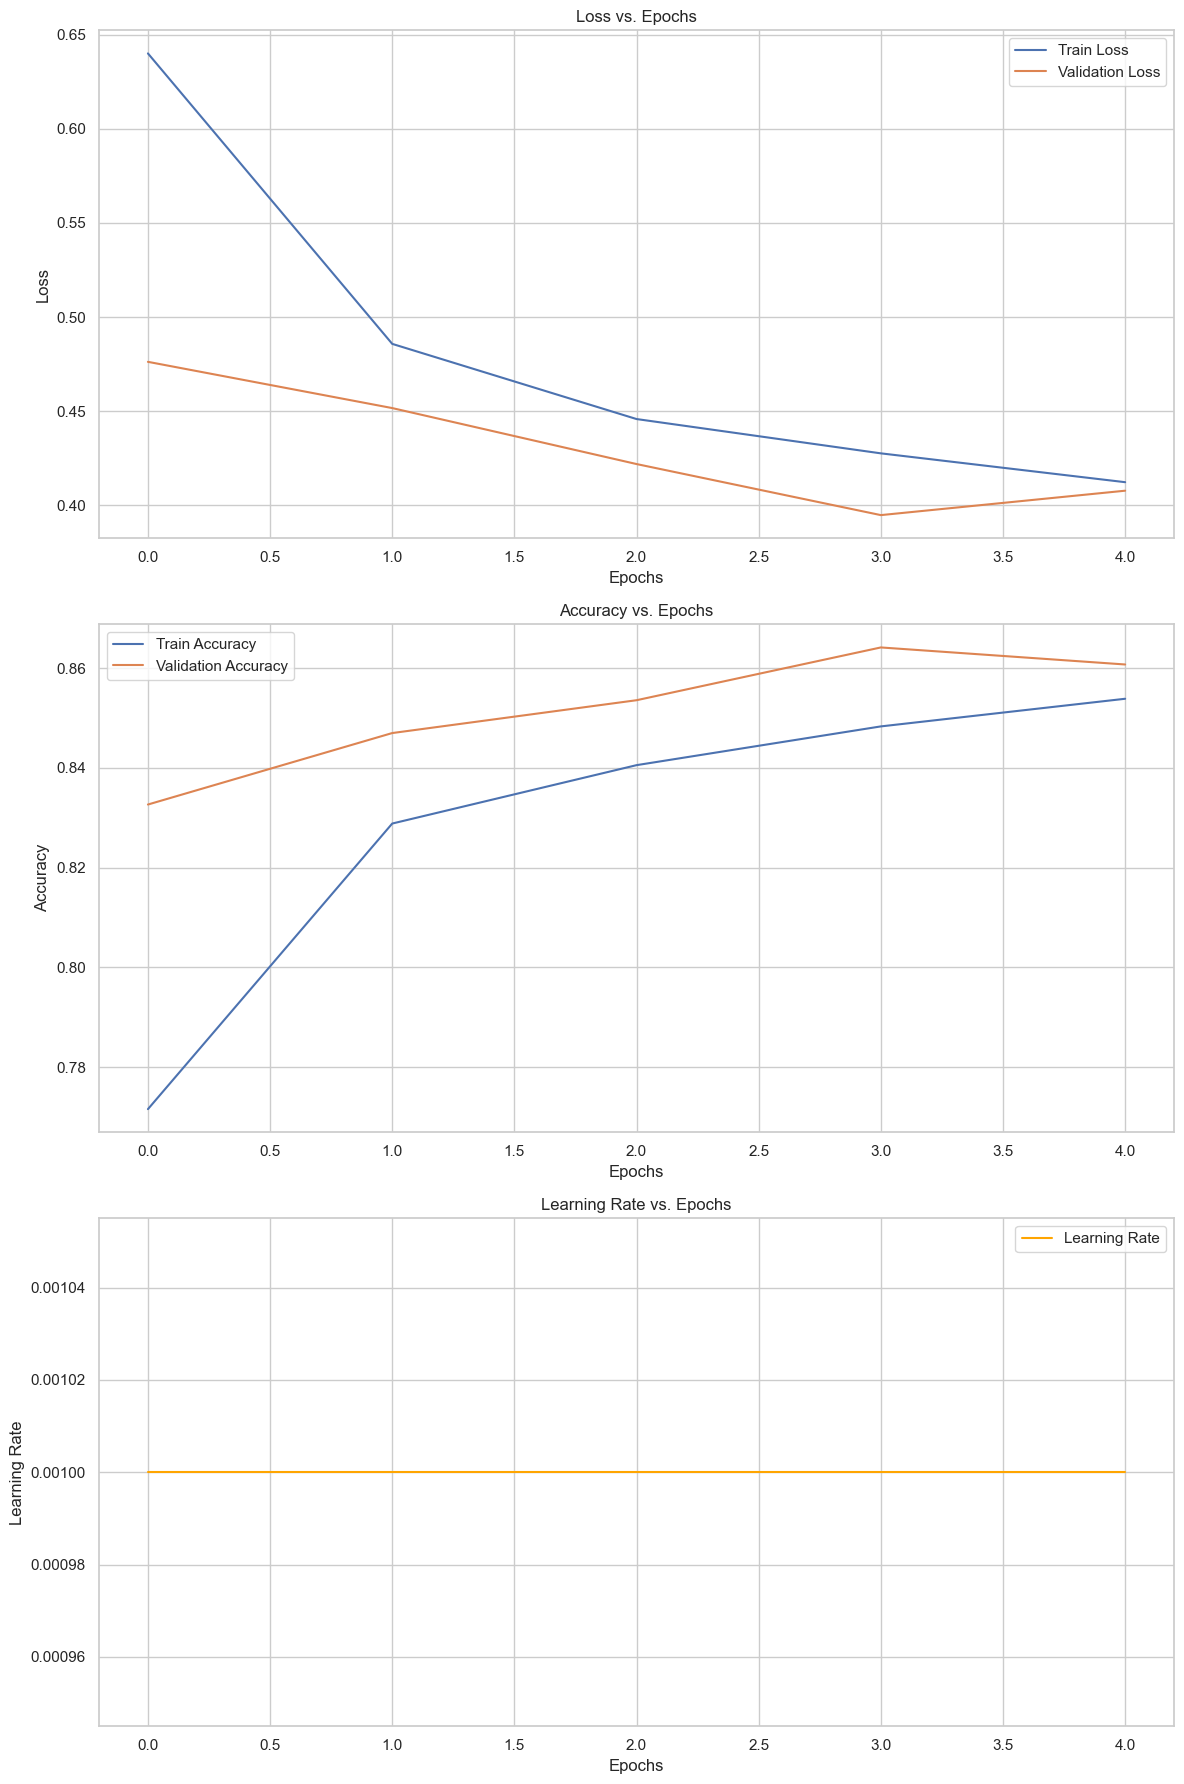


--- Starting Experiment 1b: Baseline CNN on GPU ---
Epoch 1/5 | Train Loss: 0.6536, Train Acc: 0.7691 | Val Loss: 0.4779, Val Acc: 0.8334 | LR: 0.001000
Epoch 1/5 | Train Loss: 0.6536, Train Acc: 0.7691 | Val Loss: 0.4779, Val Acc: 0.8334 | LR: 0.001000
Epoch 2/5 | Train Loss: 0.4953, Train Acc: 0.8248 | Val Loss: 0.4452, Val Acc: 0.8444 | LR: 0.001000
Epoch 2/5 | Train Loss: 0.4953, Train Acc: 0.8248 | Val Loss: 0.4452, Val Acc: 0.8444 | LR: 0.001000
Epoch 3/5 | Train Loss: 0.4524, Train Acc: 0.8425 | Val Loss: 0.4427, Val Acc: 0.8483 | LR: 0.001000
Epoch 3/5 | Train Loss: 0.4524, Train Acc: 0.8425 | Val Loss: 0.4427, Val Acc: 0.8483 | LR: 0.001000
Epoch 4/5 | Train Loss: 0.4288, Train Acc: 0.8500 | Val Loss: 0.3967, Val Acc: 0.8635 | LR: 0.001000
Epoch 4/5 | Train Loss: 0.4288, Train Acc: 0.8500 | Val Loss: 0.3967, Val Acc: 0.8635 | LR: 0.001000
Epoch 5/5 | Train Loss: 0.4126, Train Acc: 0.8544 | Val Loss: 0.3917, Val Acc: 0.8664 | LR: 0.001000
GPU Training Time: 45.63 seconds
Plot 

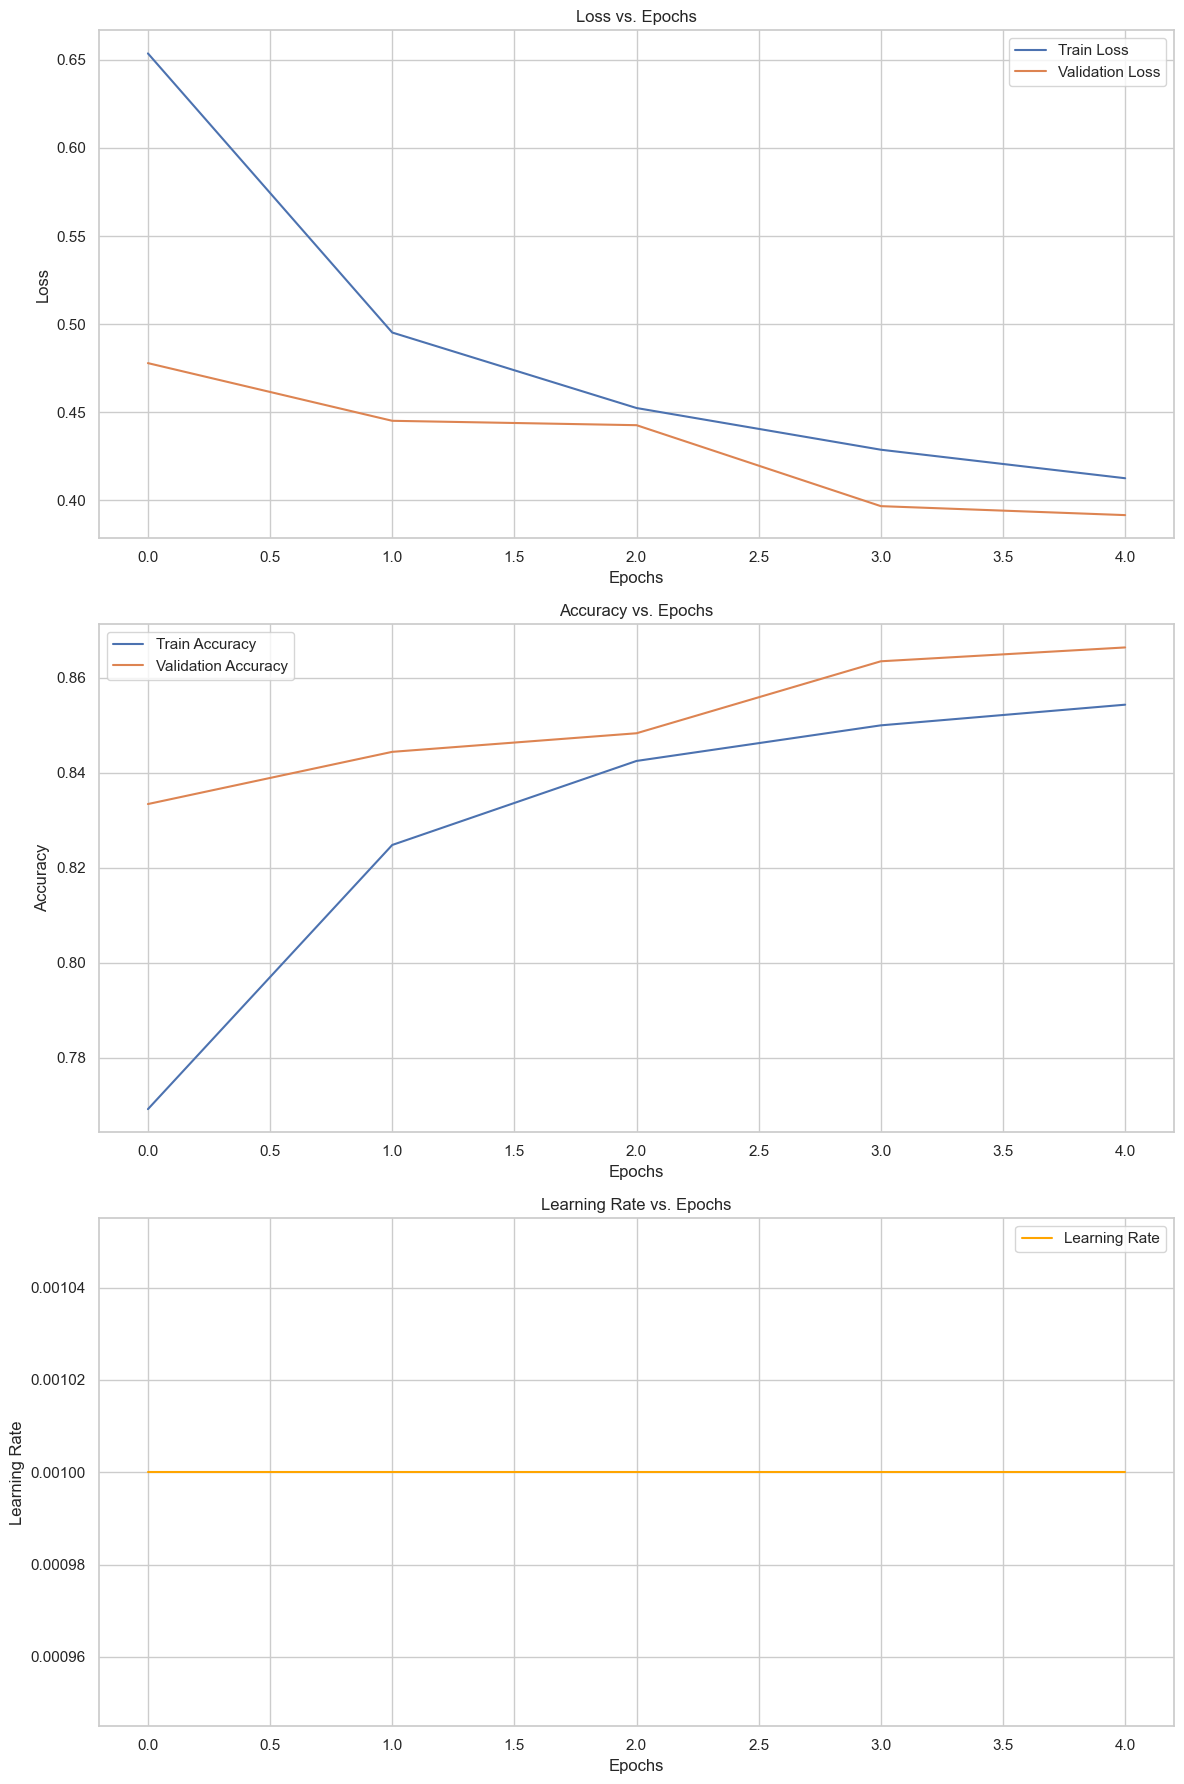


--- Performance Comparison ---
CPU Time: 54.08s
GPU Time: 45.63s
Speedup: 1.19x


In [9]:
import time

# --- Experiment 1a: Baseline CNN on CPU ---
print("--- Starting Experiment 1a: Baseline CNN on CPU ---")
# Force CPU for this run, regardless of the global `device` setting
device_cpu = torch.device("cpu")

# Instantiate a new model to ensure a fair comparison
baseline_model_cpu = BaselineCNN(num_classes=num_classes)
optimizer_cpu = optim.Adam(baseline_model_cpu.parameters(), lr=0.001)
criterion_cpu = nn.CrossEntropyLoss()

# Train on CPU
start_time_cpu = time.time()
baseline_history_cpu = train_and_validate(
    model=baseline_model_cpu,
    optimizer=optimizer_cpu,
    criterion=criterion_cpu,
    num_epochs=5,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes,
    device=device_cpu
)
end_time_cpu = time.time()
cpu_training_time = end_time_cpu - start_time_cpu
print(f"CPU Training Time: {cpu_training_time:.2f} seconds")

# Plot the results
plot_history(baseline_history_cpu, save_path='./figures/experiment_1a_cpu_history.png')

# --- Experiment 1b: Baseline CNN on GPU ---
# Only run if a GPU is available (i.e., the global `device` is not 'cpu')
if device.type != 'cpu':
    print("\n--- Starting Experiment 1b: Baseline CNN on GPU ---")
    
    # Instantiate a new model for the GPU run
    baseline_model_gpu = BaselineCNN(num_classes=num_classes)
    optimizer_gpu = optim.Adam(baseline_model_gpu.parameters(), lr=0.001)
    criterion_gpu = nn.CrossEntropyLoss()

    # Train on GPU
    start_time_gpu = time.time()
    baseline_history_gpu = train_and_validate(
        model=baseline_model_gpu,
        optimizer=optimizer_gpu,
        criterion=criterion_gpu,
        num_epochs=5,
        train_loader=train_loader,
        val_loader=val_loader,
        num_classes=num_classes,
        device=device  # Use the auto-detected GPU device
    )
    end_time_gpu = time.time()
    gpu_training_time = end_time_gpu - start_time_gpu
    print(f"GPU Training Time: {gpu_training_time:.2f} seconds")

    # Plot the results
    plot_history(baseline_history_gpu, save_path='./figures/experiment_1b_gpu_history.png')
    
    # --- Performance Comparison ---
    print("\n--- Performance Comparison ---")
    print(f"CPU Time: {cpu_training_time:.2f}s")
    print(f"GPU Time: {gpu_training_time:.2f}s")
    print(f"Speedup: {cpu_training_time / gpu_training_time:.2f}x")
else:
    print("\nGPU not available. Skipping Experiment 1b.")

### Experiment 2: Training for More Epochs

The baseline model's validation accuracy was still trending upward after 5 epochs, suggesting it was under-trained. For my next experiment, I will continue training the same `BaselineCNN` architecture but for a total of 15 epochs to see if performance improves with more training time.

Training Baseline CNN for 30 epochs...
Epoch 1/30 | Train Loss: 0.6192, Train Acc: 0.7849 | Val Loss: 0.4784, Val Acc: 0.8316 | LR: 0.00100000
Epoch 1/30 | Train Loss: 0.6192, Train Acc: 0.7849 | Val Loss: 0.4784, Val Acc: 0.8316 | LR: 0.00100000
Epoch 2/30 | Train Loss: 0.4774, Train Acc: 0.8311 | Val Loss: 0.4434, Val Acc: 0.8498 | LR: 0.00100000
Epoch 2/30 | Train Loss: 0.4774, Train Acc: 0.8311 | Val Loss: 0.4434, Val Acc: 0.8498 | LR: 0.00100000
Epoch 3/30 | Train Loss: 0.4392, Train Acc: 0.8463 | Val Loss: 0.4066, Val Acc: 0.8584 | LR: 0.00100000
Epoch 3/30 | Train Loss: 0.4392, Train Acc: 0.8463 | Val Loss: 0.4066, Val Acc: 0.8584 | LR: 0.00100000
Epoch 4/30 | Train Loss: 0.4237, Train Acc: 0.8499 | Val Loss: 0.3901, Val Acc: 0.8677 | LR: 0.00100000
Epoch 4/30 | Train Loss: 0.4237, Train Acc: 0.8499 | Val Loss: 0.3901, Val Acc: 0.8677 | LR: 0.00100000
Epoch 5/30 | Train Loss: 0.4078, Train Acc: 0.8556 | Val Loss: 0.3948, Val Acc: 0.8648 | LR: 0.00100000
Epoch 5/30 | Train Loss: 

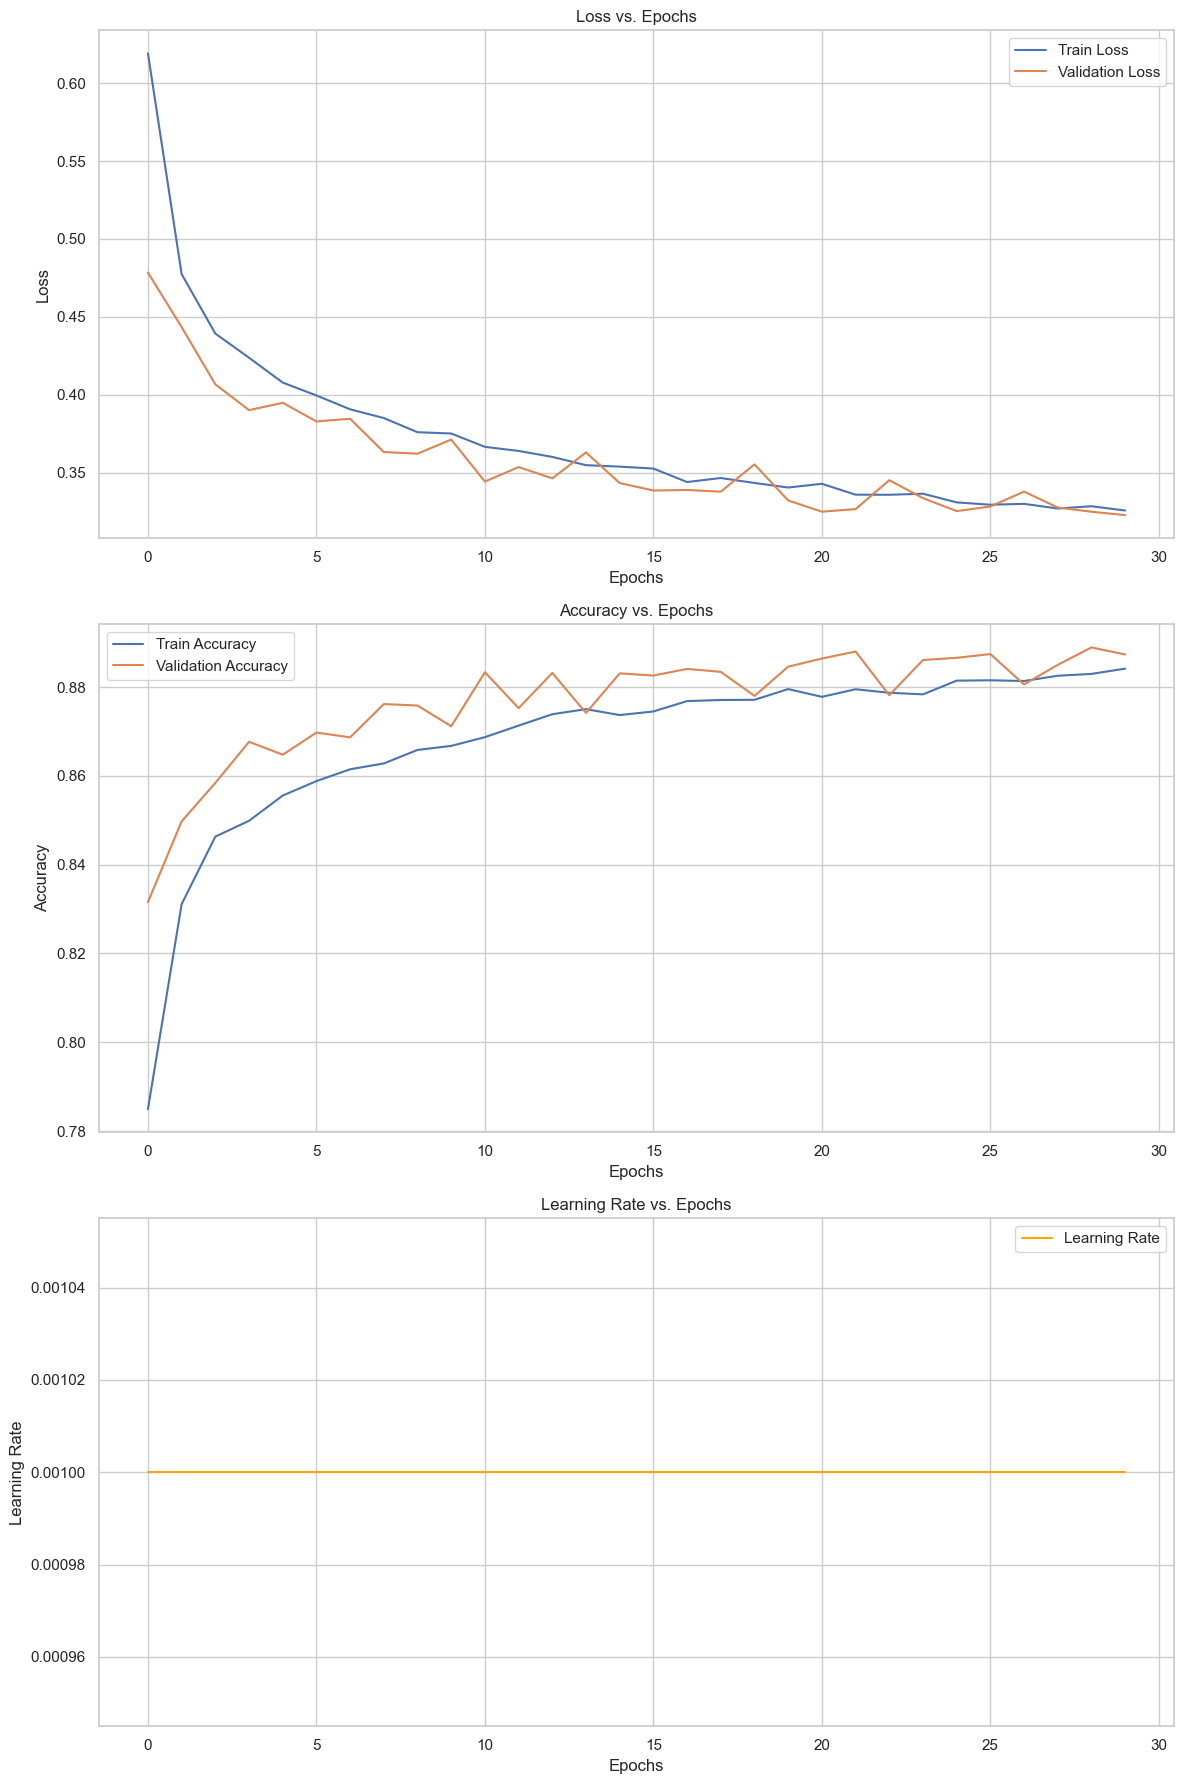

In [16]:
# Instantiate a new baseline model to train for longer
long_train_model = BaselineCNN(num_classes=num_classes)
optimizer = optim.Adam(long_train_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train for 30 epochs
print("Training Baseline CNN for 30 epochs...")
long_train_history = train_and_validate(
    model=long_train_model,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes,
    device=device
)

# Plot the results
plot_history(long_train_history, save_path='./figures/experiment_2_history.png')

### Experiment 3: Using a Deeper Network

Analysis of Experiment 2 reveals that while extending training to 30 epochs initially boosted validation accuracy, the performance gains diminished and plateaued around epoch 20. This suggests that the `BaselineCNN` has reached its learning capacity and is now likely limited by its simple architecture rather than the training duration.

To overcome this limitation, Experiment 3 will introduce a more complex model: `DeeperCNN`. By adding a second convolutional and pooling layer, this network is designed to capture more intricate features from the images. We will train it for 20 epochs, as this was the point where the baseline model's learning saturated, providing a sufficient duration to evaluate the new architecture's potential without excessive training time.

Training Deeper CNN...
Epoch 1/20 | Train Loss: 0.6586, Train Acc: 0.7609 | Val Loss: 0.4701, Val Acc: 0.8334 | LR: 0.00100000
Epoch 1/20 | Train Loss: 0.6586, Train Acc: 0.7609 | Val Loss: 0.4701, Val Acc: 0.8334 | LR: 0.00100000
Epoch 2/20 | Train Loss: 0.4823, Train Acc: 0.8252 | Val Loss: 0.3820, Val Acc: 0.8625 | LR: 0.00100000
Epoch 2/20 | Train Loss: 0.4823, Train Acc: 0.8252 | Val Loss: 0.3820, Val Acc: 0.8625 | LR: 0.00100000
Epoch 3/20 | Train Loss: 0.4357, Train Acc: 0.8406 | Val Loss: 0.3682, Val Acc: 0.8659 | LR: 0.00100000
Epoch 3/20 | Train Loss: 0.4357, Train Acc: 0.8406 | Val Loss: 0.3682, Val Acc: 0.8659 | LR: 0.00100000
Epoch 4/20 | Train Loss: 0.4068, Train Acc: 0.8511 | Val Loss: 0.3415, Val Acc: 0.8745 | LR: 0.00100000
Epoch 4/20 | Train Loss: 0.4068, Train Acc: 0.8511 | Val Loss: 0.3415, Val Acc: 0.8745 | LR: 0.00100000
Epoch 5/20 | Train Loss: 0.3905, Train Acc: 0.8577 | Val Loss: 0.3144, Val Acc: 0.8862 | LR: 0.00100000
Epoch 5/20 | Train Loss: 0.3905, Train Ac

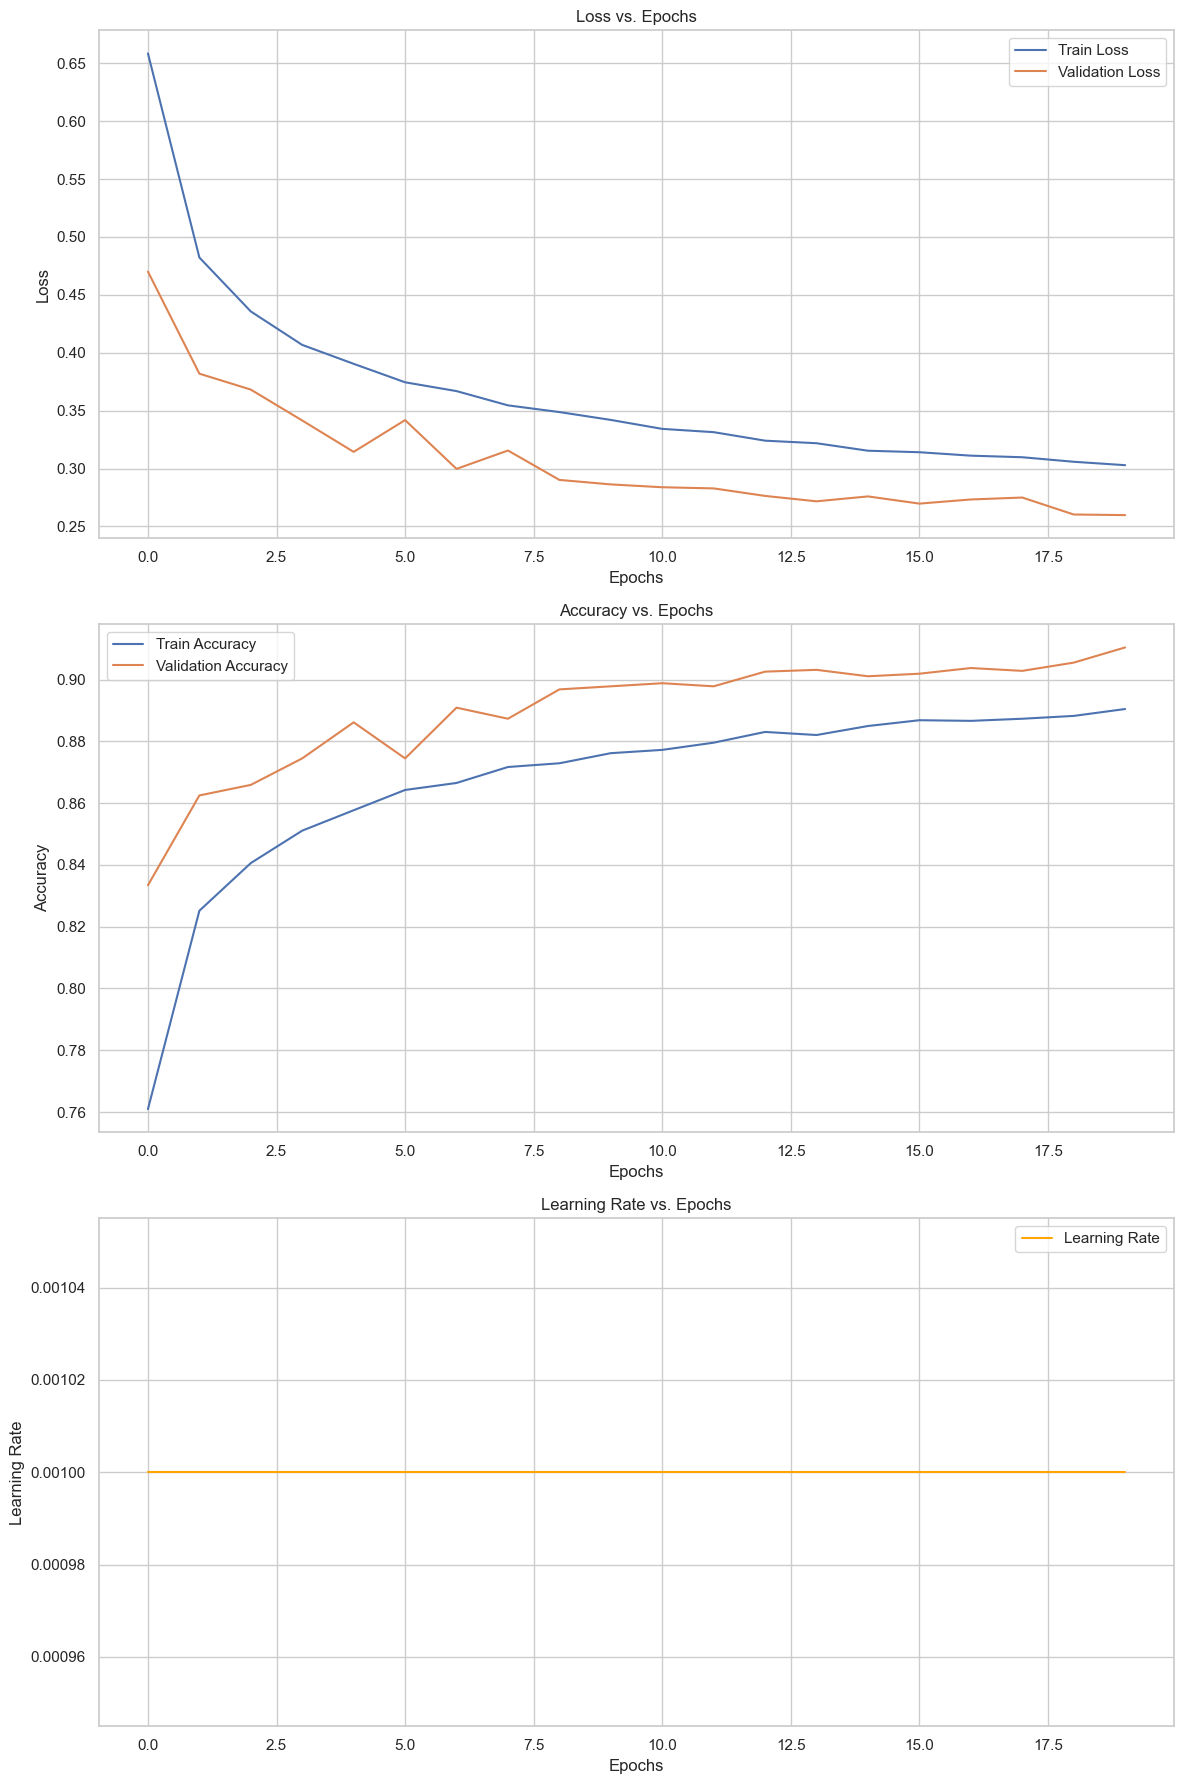

In [17]:
# Instantiate the deeper model
deeper_model = DeeperCNN(num_classes=num_classes)
optimizer = optim.Adam(deeper_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train for 20 epochs
print("Training Deeper CNN...")
deeper_history = train_and_validate(
    model=deeper_model,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=20,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes,
    device=device
)

# Plot and save the results
plot_history(deeper_history, save_path='./figures/experiment_3_history.png')

### Experiment 4: Adding Weight Decay for Regularization

In Experiment 3, the `DeeperCNN` showed strong performance. To further improve its ability to generalize and to prevent potential overfitting, this experiment introduces L2 regularization through **weight decay**.

By adding a `weight_decay` of `1e-4` to the Adam optimizer, we apply a penalty to large weights during training. This encourages the model to learn simpler patterns, which can lead to better performance on unseen data. We will train the same `DeeperCNN` for 15 epochs and compare its training history to that of Experiment 3.

Training Deeper CNN with Weight Decay...
Epoch 1/15 | Train Loss: 0.6525, Train Acc: 0.7635 | Val Loss: 0.4430, Val Acc: 0.8417 | LR: 0.00100000
Epoch 1/15 | Train Loss: 0.6525, Train Acc: 0.7635 | Val Loss: 0.4430, Val Acc: 0.8417 | LR: 0.00100000
Epoch 2/15 | Train Loss: 0.4710, Train Acc: 0.8299 | Val Loss: 0.3790, Val Acc: 0.8641 | LR: 0.00100000
Epoch 2/15 | Train Loss: 0.4710, Train Acc: 0.8299 | Val Loss: 0.3790, Val Acc: 0.8641 | LR: 0.00100000
Epoch 3/15 | Train Loss: 0.4319, Train Acc: 0.8434 | Val Loss: 0.3817, Val Acc: 0.8660 | LR: 0.00100000
Epoch 3/15 | Train Loss: 0.4319, Train Acc: 0.8434 | Val Loss: 0.3817, Val Acc: 0.8660 | LR: 0.00100000
Epoch 4/15 | Train Loss: 0.4058, Train Acc: 0.8515 | Val Loss: 0.3462, Val Acc: 0.8752 | LR: 0.00100000
Epoch 4/15 | Train Loss: 0.4058, Train Acc: 0.8515 | Val Loss: 0.3462, Val Acc: 0.8752 | LR: 0.00100000
Epoch 5/15 | Train Loss: 0.3886, Train Acc: 0.8596 | Val Loss: 0.3173, Val Acc: 0.8858 | LR: 0.00100000
Epoch 5/15 | Train Loss

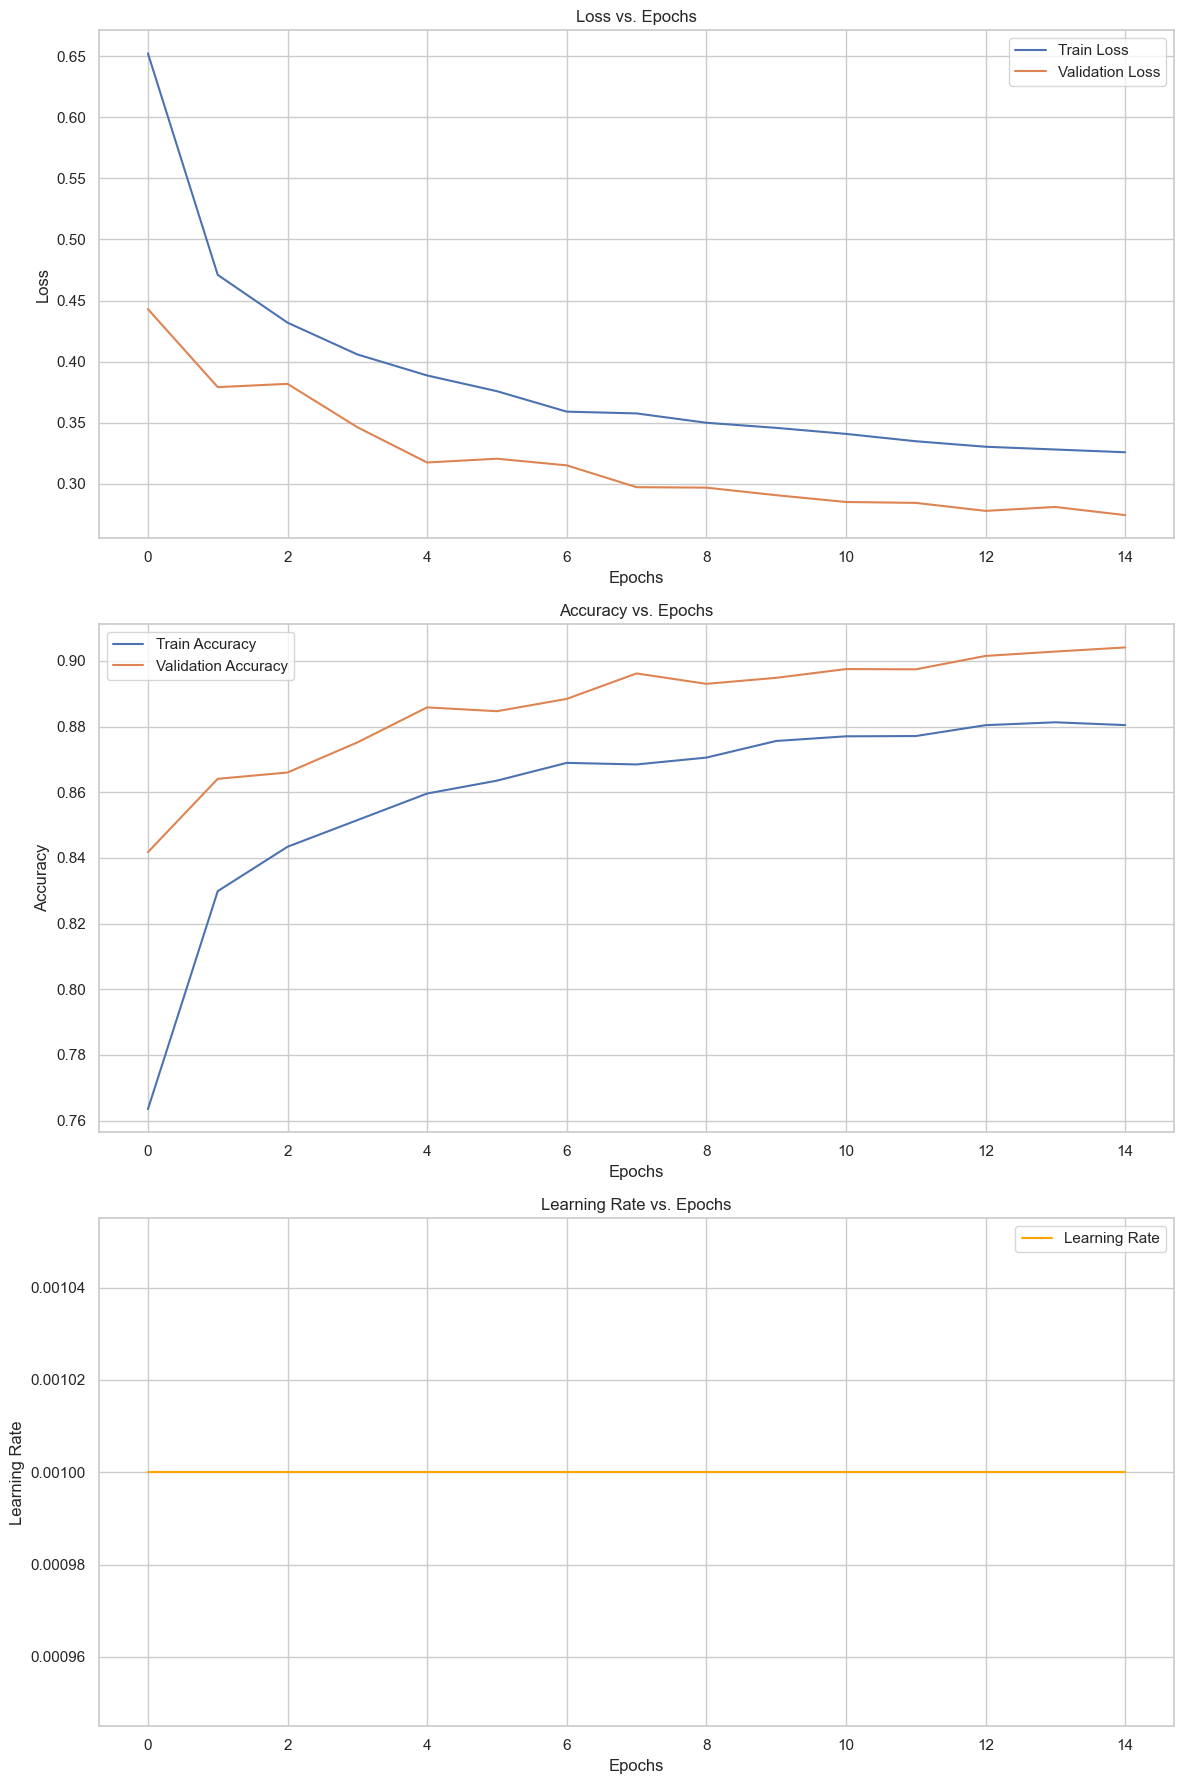

In [18]:
# Instantiate the deeper model for the new experiment
deeper_model_wd = DeeperCNN(num_classes=num_classes)

# Create an optimizer with weight decay
optimizer_wd = optim.Adam(deeper_model_wd.parameters(), lr=0.001, weight_decay=1e-4)
criterion_wd = nn.CrossEntropyLoss()

# Train for 15 epochs
print("Training Deeper CNN with Weight Decay...")
deeper_history_wd = train_and_validate(
    model=deeper_model_wd,
    optimizer=optimizer_wd,
    criterion=criterion_wd,
    num_epochs=15,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes,
    device=device
)

# Plot and save the results
plot_history(deeper_history_wd, save_path='./figures/experiment_4_wd_history.png')

### Experiment 4 Conclusion: Weight Decay

The results from Experiment 4 show that adding weight decay did not improve the model's performance. The validation accuracy was similar to the model from Experiment 3, indicating that the existing `Dropout` layer is already providing sufficient regularization for this architecture.

Therefore, the model from **Experiment 3 remains the best-performing model**. We will use this as the basis for our next experiment.

### Experiment 5: Dynamic Learning Rate with a Scheduler

Instead of manually tuning a fixed learning rate, a more sophisticated approach is to adjust it dynamically during training. This is where a **Learning Rate Scheduler** comes in.

For this experiment, we will use `ReduceLROnPlateau`, a scheduler that monitors the validation loss. If the loss fails to improve for a set number of epochs (a "patience" period), the scheduler will reduce the learning rate. This strategy allows the model to make large updates at the beginning of training and then take smaller, more precise steps as it converges on a solution.

This is a powerful technique for achieving better final performance and is a standard practice in training deep neural networks. We will train for 25 epochs to give the scheduler ample opportunity to adjust the learning rate if the model's performance plateaus.

Training Deeper CNN with Learning Rate Scheduler...
Epoch 1/25 | Train Loss: 0.6538, Train Acc: 0.7625 | Val Loss: 0.4547, Val Acc: 0.8340 | LR: 0.00100000
Epoch 1/25 | Train Loss: 0.6538, Train Acc: 0.7625 | Val Loss: 0.4547, Val Acc: 0.8340 | LR: 0.00100000
Epoch 2/25 | Train Loss: 0.4852, Train Acc: 0.8227 | Val Loss: 0.3942, Val Acc: 0.8524 | LR: 0.00100000
Epoch 2/25 | Train Loss: 0.4852, Train Acc: 0.8227 | Val Loss: 0.3942, Val Acc: 0.8524 | LR: 0.00100000
Epoch 3/25 | Train Loss: 0.4393, Train Acc: 0.8377 | Val Loss: 0.3661, Val Acc: 0.8659 | LR: 0.00100000
Epoch 3/25 | Train Loss: 0.4393, Train Acc: 0.8377 | Val Loss: 0.3661, Val Acc: 0.8659 | LR: 0.00100000
Epoch 4/25 | Train Loss: 0.4084, Train Acc: 0.8511 | Val Loss: 0.3451, Val Acc: 0.8769 | LR: 0.00100000
Epoch 4/25 | Train Loss: 0.4084, Train Acc: 0.8511 | Val Loss: 0.3451, Val Acc: 0.8769 | LR: 0.00100000
Epoch 5/25 | Train Loss: 0.3915, Train Acc: 0.8582 | Val Loss: 0.3174, Val Acc: 0.8860 | LR: 0.00100000
Epoch 5/25 |

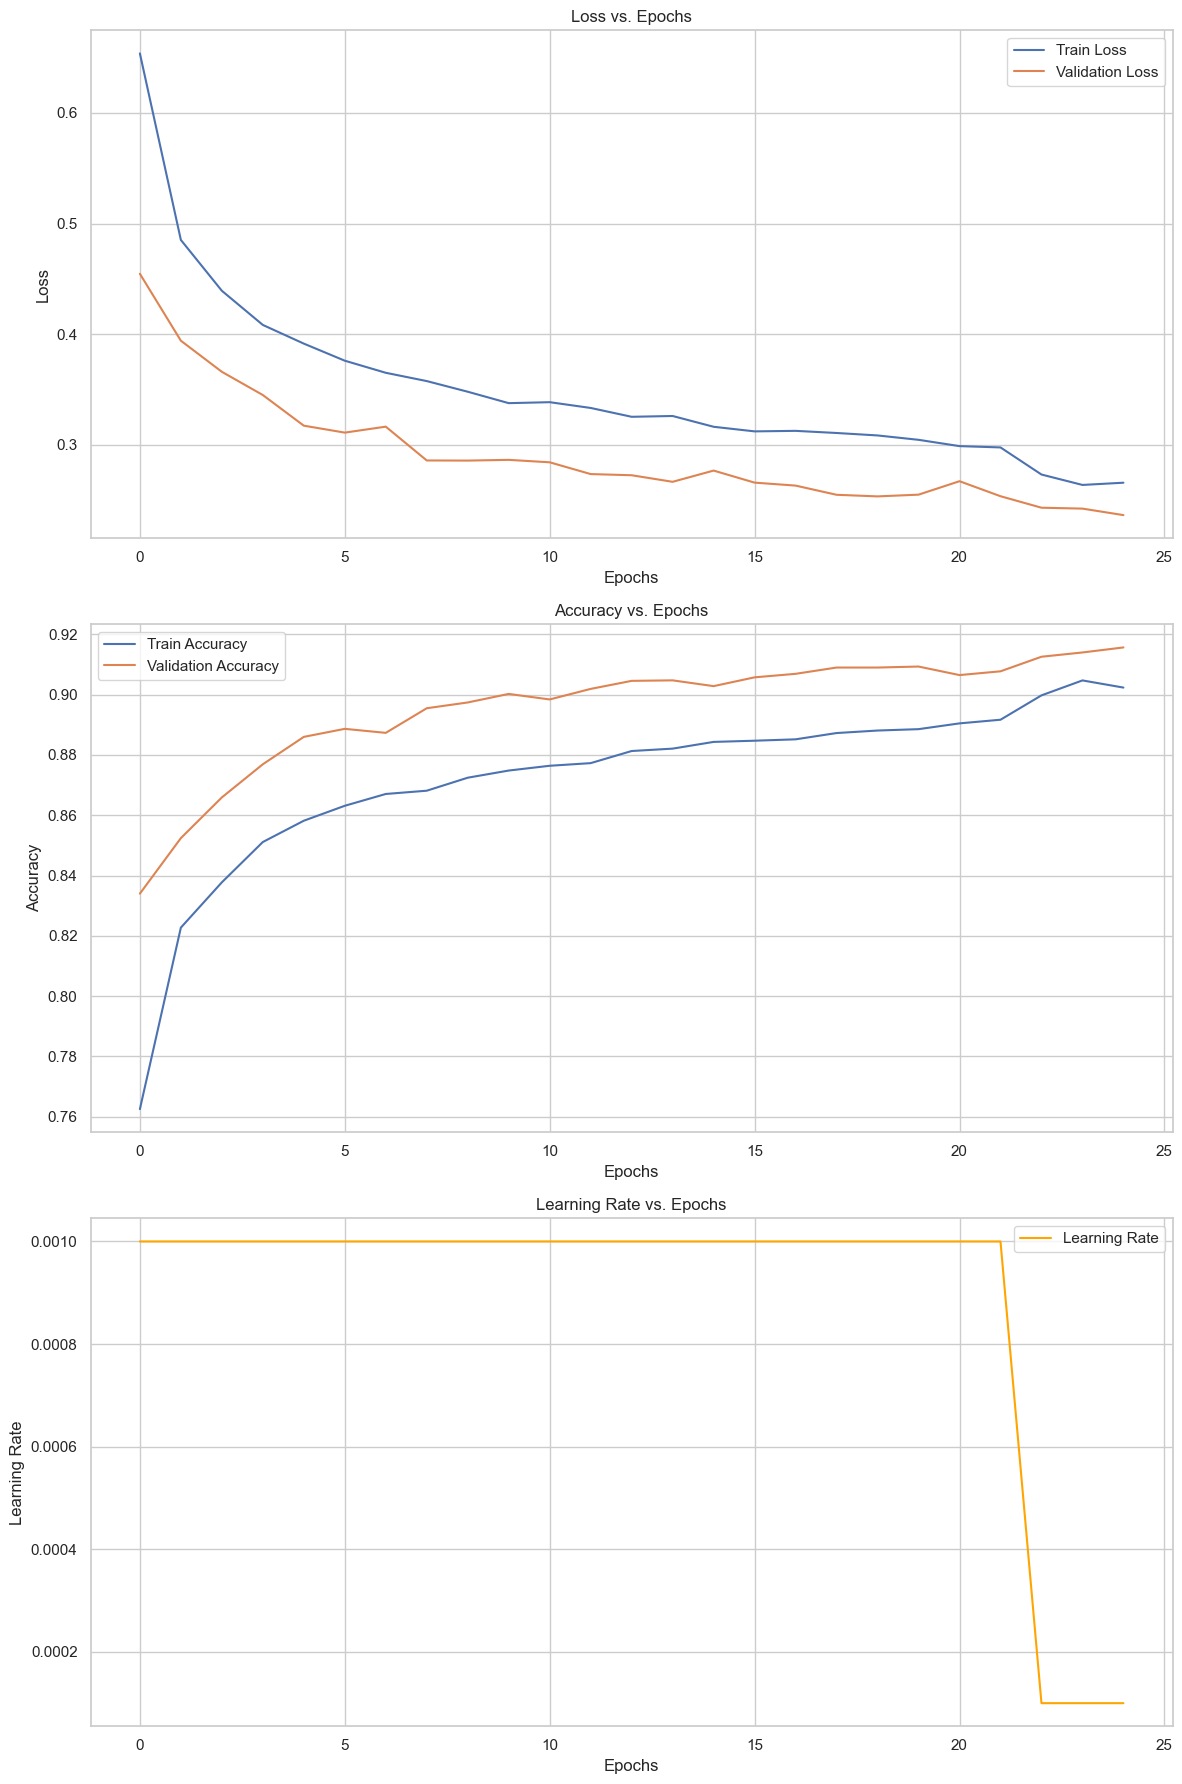

In [19]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Instantiate the deeper model for the new experiment
deeper_model_lr = DeeperCNN(num_classes=num_classes)

# Use the standard learning rate, as the scheduler will manage it
optimizer_lr = optim.Adam(deeper_model_lr.parameters(), lr=0.001)
criterion_lr = nn.CrossEntropyLoss()

# Define the scheduler
# It will reduce the LR by a factor of 0.1 if val_loss doesn't improve for 2 epochs.
scheduler = ReduceLROnPlateau(optimizer_lr, mode='min', factor=0.1, patience=2)

# Train for 25 epochs to give the scheduler time to work
print("Training Deeper CNN with Learning Rate Scheduler...")
deeper_history_lr = train_and_validate(
    model=deeper_model_lr,
    optimizer=optimizer_lr,
    criterion=criterion_lr,
    num_epochs=25,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes,
    device=device,
    scheduler=scheduler  # Pass the scheduler to the training function
)

# Plot and save the results
plot_history(deeper_history_lr, save_path='./figures/experiment_5_lr_scheduler_history.png')

### Experiment 6: Forcing the Plateau with Longer Training and More Aggressive Scheduling

Experiment 5 showed very healthy training, but the learning rate scheduler never activated because the validation loss was always improving. To truly test the model's limits and see the scheduler in action, this experiment will be more aggressive.

We will make two changes:
1.  **Increase Epochs to 40**: This provides a much longer runway to see if the model's performance eventually plateaus.
2.  **Decrease Scheduler Patience to 1**: The scheduler will now reduce the learning rate if the validation loss fails to improve for even a single epoch.

This rigorous test will help us find the true convergence point of our `DeeperCNN` with `ELU` activations and determine its peak performance.

Training Deeper CNN with Aggressive Learning Rate Scheduler...
Epoch 1/40 | Train Loss: 0.6626, Train Acc: 0.7592 | Val Loss: 0.4544, Val Acc: 0.8358 | LR: 0.00100000
Epoch 1/40 | Train Loss: 0.6626, Train Acc: 0.7592 | Val Loss: 0.4544, Val Acc: 0.8358 | LR: 0.00100000
Epoch 2/40 | Train Loss: 0.4968, Train Acc: 0.8193 | Val Loss: 0.4188, Val Acc: 0.8449 | LR: 0.00100000
Epoch 2/40 | Train Loss: 0.4968, Train Acc: 0.8193 | Val Loss: 0.4188, Val Acc: 0.8449 | LR: 0.00100000
Epoch 3/40 | Train Loss: 0.4432, Train Acc: 0.8385 | Val Loss: 0.3625, Val Acc: 0.8691 | LR: 0.00100000
Epoch 3/40 | Train Loss: 0.4432, Train Acc: 0.8385 | Val Loss: 0.3625, Val Acc: 0.8691 | LR: 0.00100000
Epoch 4/40 | Train Loss: 0.4166, Train Acc: 0.8479 | Val Loss: 0.3400, Val Acc: 0.8736 | LR: 0.00100000
Epoch 4/40 | Train Loss: 0.4166, Train Acc: 0.8479 | Val Loss: 0.3400, Val Acc: 0.8736 | LR: 0.00100000
Epoch 5/40 | Train Loss: 0.3913, Train Acc: 0.8574 | Val Loss: 0.3301, Val Acc: 0.8816 | LR: 0.00100000
E

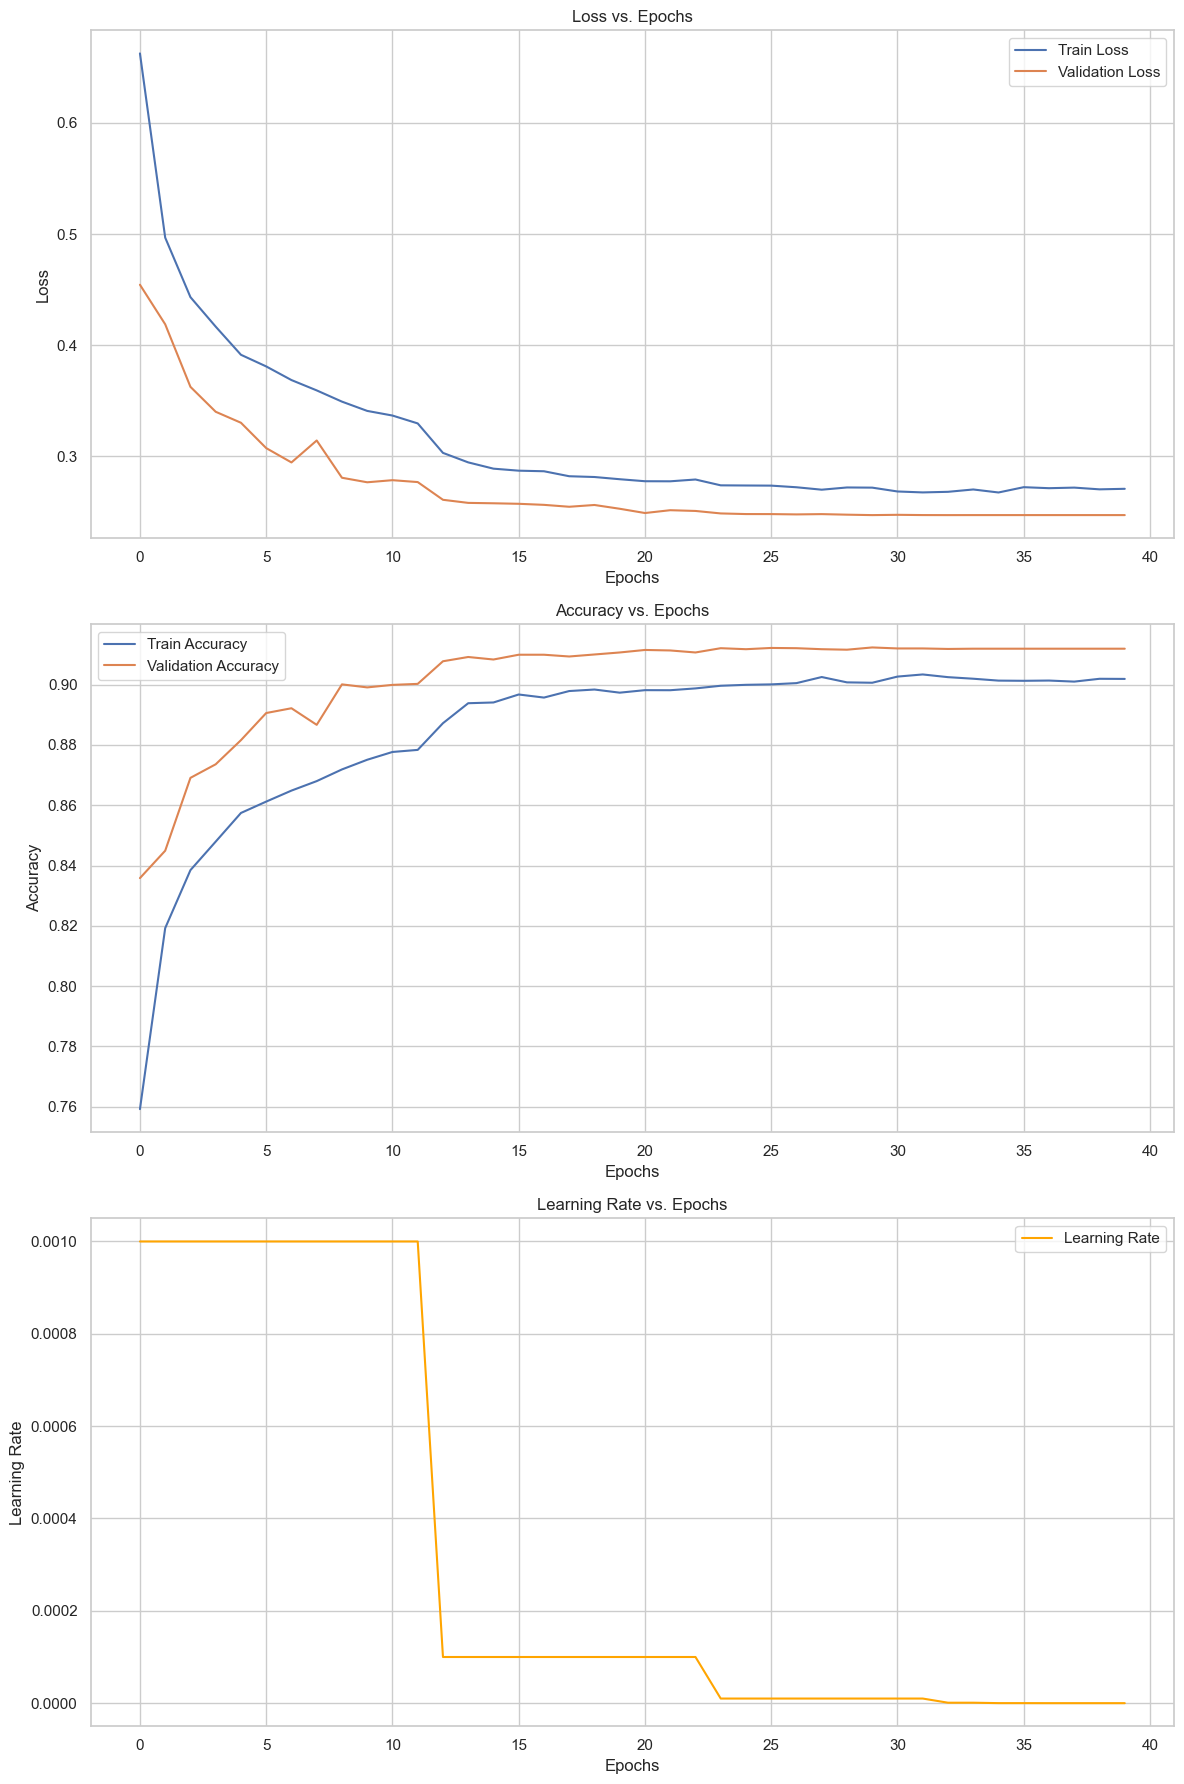

In [6]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Instantiate the deeper model for the new experiment
deeper_model_exp6 = DeeperCNN(num_classes=num_classes)

# Use the standard learning rate
optimizer_exp6 = optim.Adam(deeper_model_exp6.parameters(), lr=0.001)
criterion_exp6 = nn.CrossEntropyLoss()

# Define the more aggressive scheduler
scheduler_exp6 = ReduceLROnPlateau(optimizer_exp6, mode='min', factor=0.1, patience=1)

# Train for 40 epochs
print("Training Deeper CNN with Aggressive Learning Rate Scheduler...")
deeper_history_exp6 = train_and_validate(
    model=deeper_model_exp6,
    optimizer=optimizer_exp6,
    criterion=criterion_exp6,
    num_epochs=40,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes,
    device=device,
    scheduler=scheduler_exp6
)

# Plot and save the results
plot_history(deeper_history_exp6, save_path='./figures/experiment_6_lr_scheduler_history.png')

### Final Model Evaluation

After a series of rigorous experiments, the model from **Experiment 5**—which used the `DeeperCNN` with `ELU` activations and a `ReduceLROnPlateau` learning rate scheduler—has emerged as our top performer.

I have selected this as the final model. Now, I will perform a definitive evaluation on the held-out test set, which the model has not seen before. This will provide an unbiased assessment of its real-world performance.

The evaluation will include:
-   Overall test accuracy.
-   Per-class precision and recall to understand its strengths and weaknesses.
-   A confusion matrix to visualize misclassifications.

# Evaluate the best model on the test set


Evaluating Experiment 5 model on the test set...
Overall Test Accuracy: 0.9090

Per-Class Precision and Recall:
T-shirt/top : Precision=0.8587, Recall=0.8570
Trouser     : Precision=0.9909, Recall=0.9840
Pullover    : Precision=0.8608, Recall=0.8660
Dress       : Precision=0.9011, Recall=0.9110
Coat        : Precision=0.8405, Recall=0.8750
Sandal      : Precision=0.9878, Recall=0.9720
Shirt       : Precision=0.7550, Recall=0.7120
Sneaker     : Precision=0.9464, Recall=0.9710
Bag         : Precision=0.9790, Recall=0.9810
Ankle boot  : Precision=0.9649, Recall=0.9610
Overall Test Accuracy: 0.9090

Per-Class Precision and Recall:
T-shirt/top : Precision=0.8587, Recall=0.8570
Trouser     : Precision=0.9909, Recall=0.9840
Pullover    : Precision=0.8608, Recall=0.8660
Dress       : Precision=0.9011, Recall=0.9110
Coat        : Precision=0.8405, Recall=0.8750
Sandal      : Precision=0.9878, Recall=0.9720
Shirt       : Precision=0.7550, Recall=0.7120
Sneaker     : Precision=0.9464, Recall=0.97

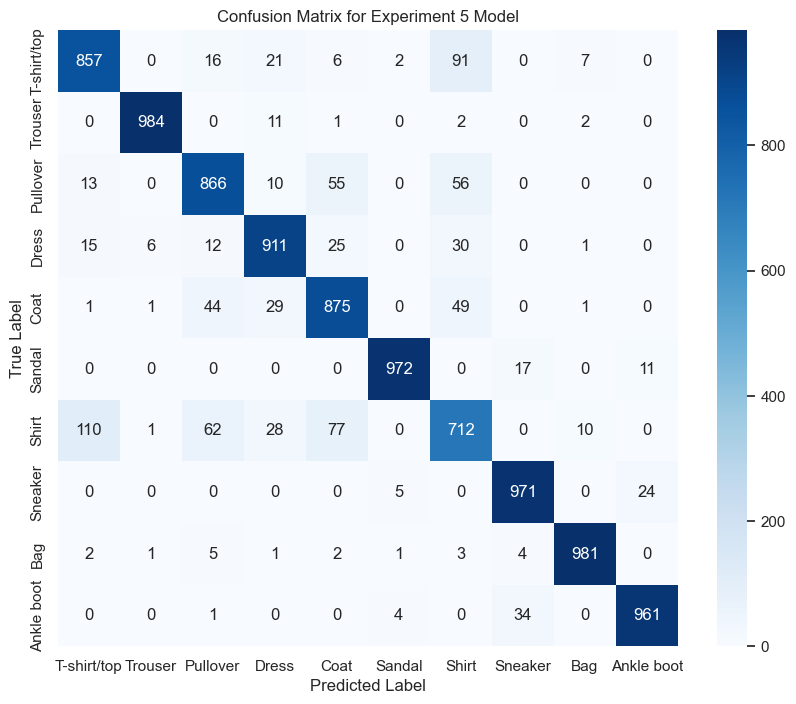

In [25]:
from sklearn.metrics import confusion_matrix

print("Evaluating Experiment 5 model on the test set...")
accuracy, precision, recall, all_labels, all_preds = evaluate_model(deeper_model_lr, test_loader, classes, device);

# Save the confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix for Experiment 5 Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('./figures/confusion_matrix_exp5.png')
plt.show()

### Save the Final Model

To make the model usable for future inference without retraining, I will save its learned parameters (the `state_dict`) to a file. This is a crucial step for deploying the model into a production environment.

In [26]:
# Save the model state dictionary
model_save_path = "fashion_mnist_cnn_exp5.pth"
torch.save(deeper_model_lr.state_dict(), model_save_path)
print(f"Model from Experiment 5 saved to {model_save_path}")

Model from Experiment 5 saved to fashion_mnist_cnn_exp5.pth


### Experiment Performance Comparison

To provide a clear overview of how each experiment impacted performance, this section consolidates the results from all six models. I will evaluate each model on the held-out test set to gather its final accuracy, precision, and recall.

The following visualizations will compare:
1.  **Overall Accuracy**: A bar chart showing the final test accuracy of each model.
2.  **Per-Class Precision**: A grouped bar chart to compare how precisely each model identifies items within each class.
3.  **Per-Class Recall**: A grouped bar chart to compare how effectively each model finds all items of a given class.

This comparative analysis will highlight the effectiveness of the techniques applied in each experiment, such as deeper architecture, regularization, and learning rate scheduling.

In [21]:
import pandas as pd

# --- Evaluate All Models ---
print("Evaluating all experimental models on the test set...")

# It's good practice to set models to evaluation mode
baseline_model.eval()
long_train_model.eval()
deeper_model.eval()
deeper_model_wd.eval()
deeper_model_lr.eval()
deeper_model_exp6.eval()

models_to_evaluate = {
    "Exp 1: Baseline": baseline_model,
    "Exp 2: Baseline (30 Epochs)": long_train_model,
    "Exp 3: DeeperCNN": deeper_model,
    "Exp 4: DeeperCNN + WD": deeper_model_wd,
    "Exp 5: DeeperCNN + LR Scheduler": deeper_model_lr,
    "Exp 6: DeeperCNN + Aggressive LR": deeper_model_exp6,
}

performance_data = {}

with torch.no_grad():
    for name, model in models_to_evaluate.items():
        print(f"--- Evaluating {name} ---")
        accuracy, precision, recall, _, _ = evaluate_model(model, test_loader, classes, device)
        performance_data[name] = {
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall
        }

# Convert to DataFrame for easier plotting
performance_df = pd.DataFrame.from_dict(performance_data, orient='index')
print("\n--- All Model Performance ---")
print(performance_df[["Accuracy"]])

Evaluating all experimental models on the test set...
--- Evaluating Exp 1: Baseline ---
Overall Test Accuracy: 0.8609

Per-Class Precision and Recall:
T-shirt/top : Precision=0.8361, Recall=0.7600
Trouser     : Precision=0.9866, Recall=0.9600
Pullover    : Precision=0.8012, Recall=0.8140
Dress       : Precision=0.8671, Recall=0.8550
Coat        : Precision=0.7591, Recall=0.8510
Sandal      : Precision=0.9576, Recall=0.9250
Shirt       : Precision=0.6420, Recall=0.6240
Sneaker     : Precision=0.8778, Recall=0.9630
Bag         : Precision=0.9459, Recall=0.9450
Ankle boot  : Precision=0.9490, Recall=0.9120
--- Evaluating Exp 2: Baseline (30 Epochs) ---
Overall Test Accuracy: 0.8609

Per-Class Precision and Recall:
T-shirt/top : Precision=0.8361, Recall=0.7600
Trouser     : Precision=0.9866, Recall=0.9600
Pullover    : Precision=0.8012, Recall=0.8140
Dress       : Precision=0.8671, Recall=0.8550
Coat        : Precision=0.7591, Recall=0.8510
Sandal      : Precision=0.9576, Recall=0.9250
Sh

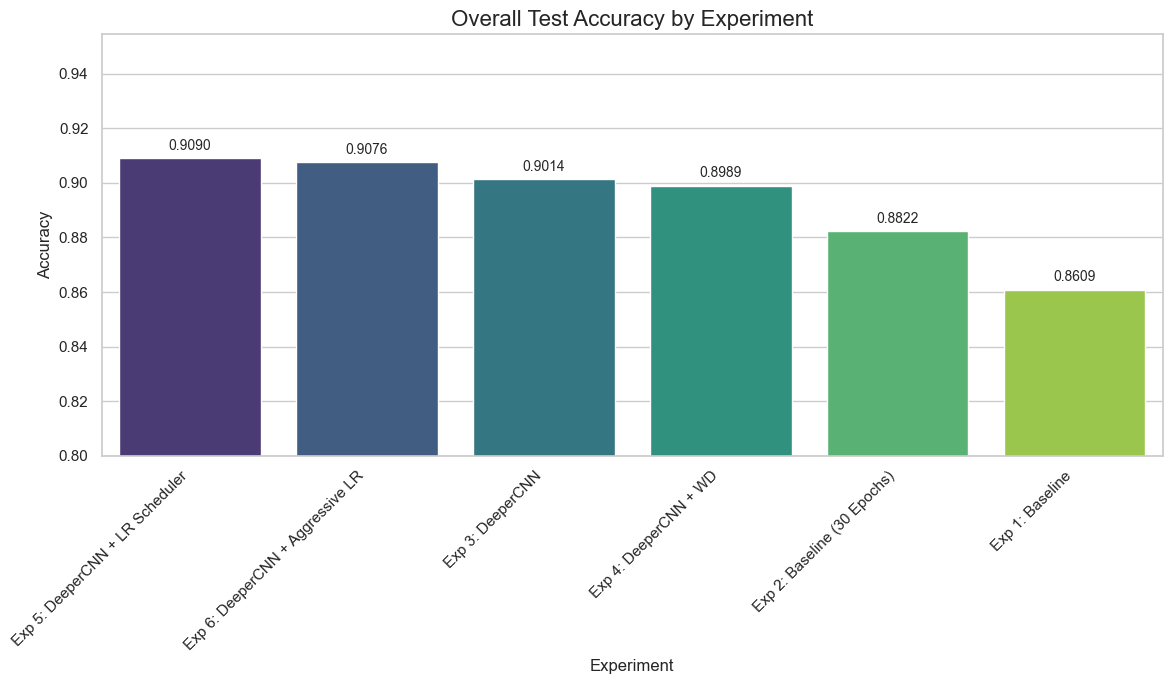

In [22]:
# --- Plot Overall Accuracy ---
plt.figure(figsize=(12, 7))
accuracy_series = performance_df['Accuracy'].sort_values(ascending=False)
sns.barplot(x=accuracy_series.index, y=accuracy_series.values, palette='viridis', hue=accuracy_series.index, dodge=False)
plt.title('Overall Test Accuracy by Experiment', fontsize=16)
plt.xlabel('Experiment', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, accuracy_series.max() * 1.05) # Adjust y-axis to zoom in on the differences
plt.legend([],[], frameon=False)
# Add text labels for each bar
for i, acc in enumerate(accuracy_series.values):
    plt.text(i, acc + 0.002, f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('./figures/comparison_accuracy.png')
plt.show()

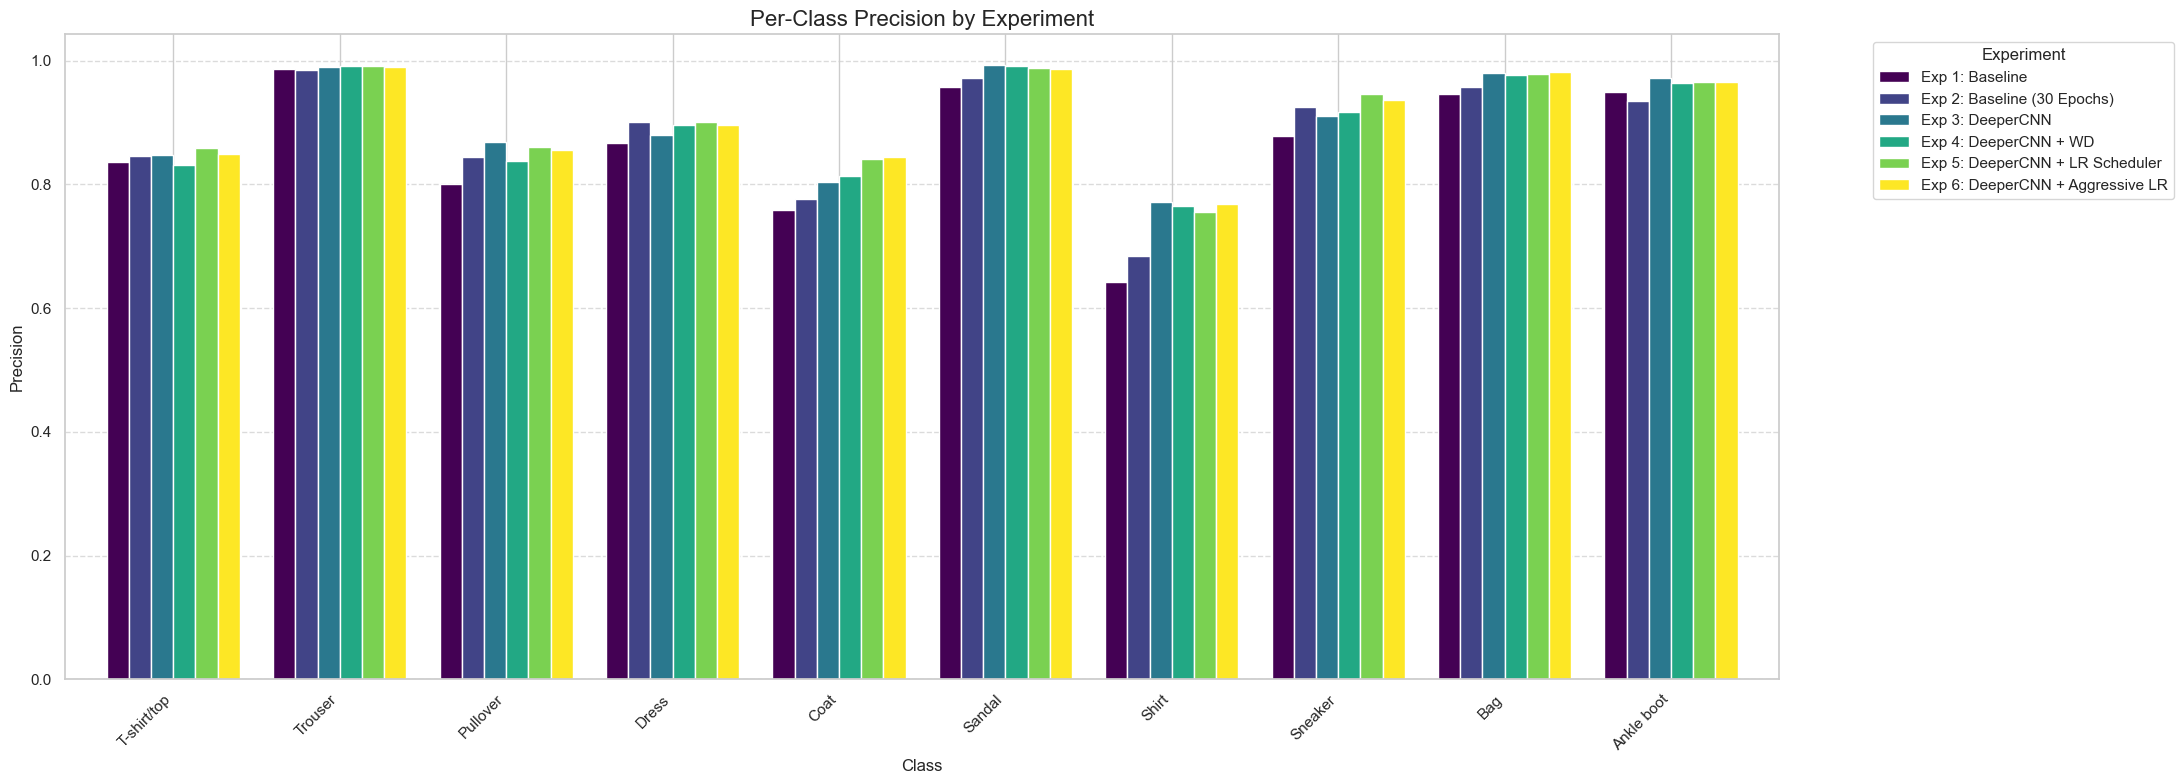

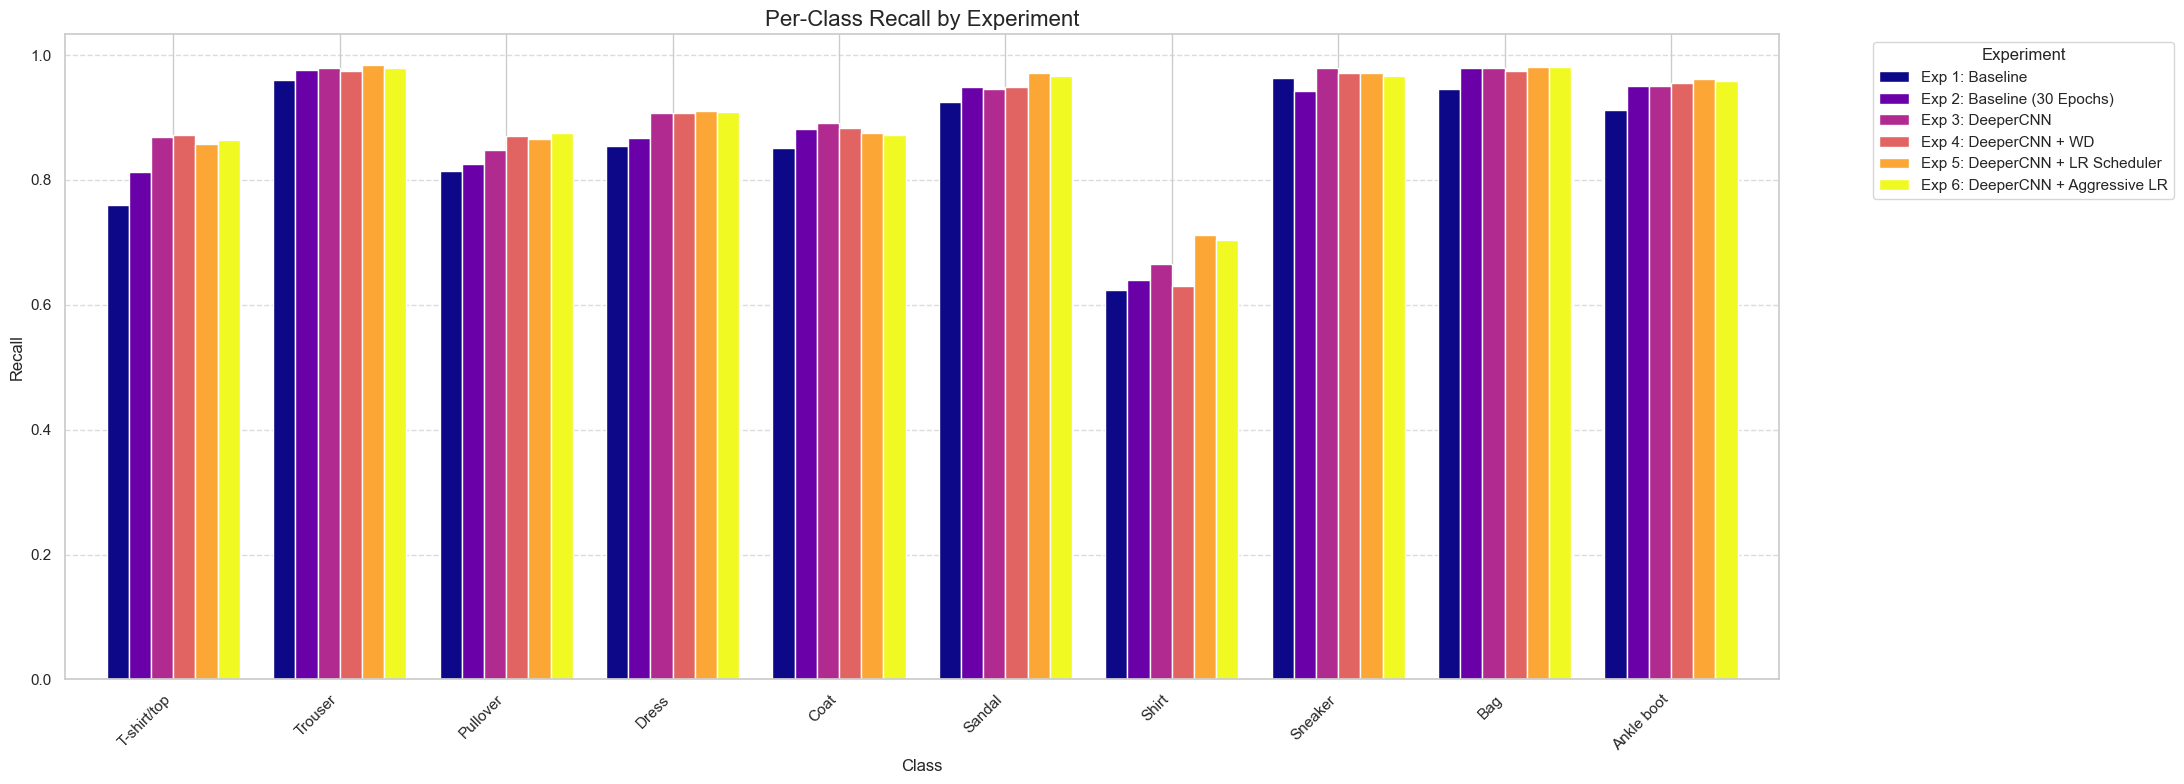

In [24]:
# --- Plot Per-Class Precision and Recall ---

# Extract the per-class metrics into a more usable format
precision_data = {name: results['Precision'] for name, results in performance_data.items()}
recall_data = {name: results['Recall'] for name, results in performance_data.items()}

precision_df = pd.DataFrame(precision_data, index=classes)
recall_df = pd.DataFrame(recall_data, index=classes)

# Plot Precision
precision_df.plot(kind='bar', figsize=(22, 8), width=0.8, colormap='viridis')
plt.title('Per-Class Precision by Experiment', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Experiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('./figures/comparison_precision.png')
plt.show()

# Plot Recall
recall_df.plot(kind='bar', figsize=(22, 8), width=0.8, colormap='plasma')
plt.title('Per-Class Recall by Experiment', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Experiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('./figures/comparison_recall.png')
plt.show()